In [11]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

files = [
    "003_2006_2080_352_360.nc",
    "004_2006_2080_352_360.nc",
    "005_2006_2080_352_360.nc",
    "006_2006_2080_352_360.nc",
    "007_2006_2080_352_360.nc",
    "008_2006_2080_352_360.nc"
]

1. 正在解析 actualdata.nc ...
✅ 真实数据提取完成。
2. 正在解析 003-008.nc 气候模拟数据并构建特征 ...
3. 正在训练 Gradient Boosting 模型并预测 2050-2080 ...
✅ 模型训练与未来预测完成。
4. 计算真实数据误差并生成可视化 ...

【模型基准校验报告 (2006-2026)】
年均温系统偏差 (Bias): 6.45 °C (正数表示模型偏热，负数表示偏冷)
均方根误差 (RMSE): 6.55 °C



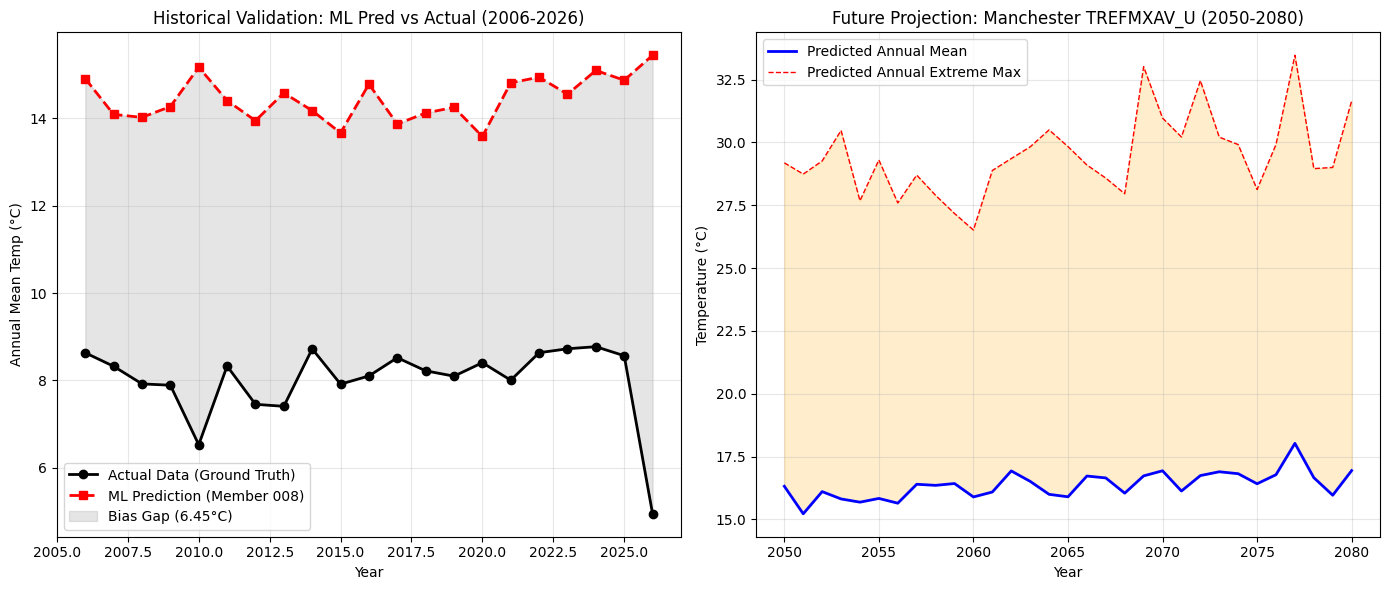

In [14]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# ==============================================================================
# 第一步：提取真实观测数据 (actualdata.nc) 中的曼彻斯特历史气温 (2006-2026)
# ==============================================================================
print("1. 正在解析 actualdata.nc ...")
try:
    with h5py.File('actualdata.nc', 'r') as f_actual:
        # 提取时间 (修复了 utcfromtimestamp 的弃用警告)
        vt_unix = f_actual['valid_time'][:]
        dates_actual = pd.to_datetime([
            datetime.datetime.fromtimestamp(t, datetime.timezone.utc) for t in vt_unix
        ]).tz_localize(None) # 移除时区信息以便后续对齐
        
        # 寻找曼彻斯特 (53.48 N, -2.24 W) 最近的经纬度索引
        lats_actual = f_actual['latitude'][:]
        lons_actual = f_actual['longitude'][:]
        lat_idx_actual = np.abs(lats_actual - 53.48).argmin()
        lon_idx_actual = np.abs(lons_actual - (-2.24)).argmin()
        
        # 提取 2米温度并转换为摄氏度
        t2m_raw = f_actual['t2m'][:, lat_idx_actual, lon_idx_actual]
        t2m = np.where(t2m_raw > 1e30, np.nan, t2m_raw)
        temp_actual_c = t2m - 273.15
        
        df_actual = pd.DataFrame({'Date': dates_actual, 'Actual_Temp': temp_actual_c})
        df_actual['Year'] = df_actual['Date'].dt.year
        
        # 过滤对齐到 2006 - 2026 年
        df_actual = df_actual[(df_actual['Year'] >= 2006) & (df_actual['Year'] <= 2026)]
        annual_actual = df_actual.groupby('Year')['Actual_Temp'].mean()
        print("✅ 真实数据提取完成。")
except Exception as e:
    print(f"读取 actualdata.nc 失败: {e}")

# ==============================================================================
# 第二步：提取气候模拟数据 (003-008) 并进行特征工程
# ==============================================================================
print("2. 正在解析 003-008.nc 气候模拟数据并构建特征 ...")
sim_files = [
    "003_2006_2080_352_360.nc", "004_2006_2080_352_360.nc",
    "005_2006_2080_352_360.nc", "006_2006_2080_352_360.nc",
    "007_2006_2080_352_360.nc", "008_2006_2080_352_360.nc"
]

def load_sim_data(filename):
    with h5py.File(filename, 'r') as f:
        c_lat, c_lon = 5, 3  # 曼彻斯特区域索引
        
        # 目标变量与预测变量
        vars_to_load = ['TREFHT', 'QBOT', 'UBOT', 'VBOT', 'FSNS', 'FLNS', 'PRECT', 'TREFMXAV_U']
        data_dict = {}
        
        for v in vars_to_load:
            d = f[v][:, c_lat, c_lon]
            d[d > 1e30] = np.nan
            if 'TREF' in v: 
                d -= 273.15  # 转为摄氏度
            data_dict[v] = d
            
        df = pd.DataFrame(data_dict)
        n_days = len(df)
        df['Year'] = 2006 + (np.arange(n_days) // 365)
        df['DayOfYear'] = (np.arange(n_days) % 365) + 1
        df['Target_Lag1'] = df['TREFMXAV_U'].shift(1)
        return df.dropna().reset_index(drop=True)

# 003-007 用于训练
train_dfs = [load_sim_data(f) for f in sim_files[:-1]]
df_train = pd.concat(train_dfs, ignore_index=True)

# 008 用于测试与预测
df_test = load_sim_data(sim_files[-1])                  

features = ['TREFHT', 'QBOT', 'UBOT', 'VBOT', 'FSNS', 'FLNS', 'PRECT', 'DayOfYear', 'Target_Lag1']
X_train, y_train = df_train[features], df_train['TREFMXAV_U']
X_test, y_test = df_test[features], df_test['TREFMXAV_U']

# ==============================================================================
# 第三步：机器学习建模与预测 (2050 - 2080)
# ==============================================================================
print("3. 正在训练 Gradient Boosting 模型并预测 2050-2080 ...")
# 使用 Gradient Boosting 作为主力模型
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)

# 预测整个测试集 (Member 008)
df_test['Predicted_TREFMXAV_U'] = gb_model.predict(X_test)

# 提取 2050-2080 的预测结果
df_pred_future = df_test[(df_test['Year'] >= 2050) & (df_test['Year'] <= 2080)]

print("✅ 模型训练与未来预测完成。")

# ==============================================================================
# 第四步：模型表现检验与历史误差对比 (Validation against Actual)
# ==============================================================================
print("4. 计算真实数据误差并生成可视化 ...")

# 提取模型在 2006-2026 的预测结果
df_pred_history = df_test[(df_test['Year'] >= 2006) & (df_test['Year'] <= 2026)]
annual_pred_history = df_pred_history.groupby('Year')['Predicted_TREFMXAV_U'].mean()

if 'annual_actual' in locals():
    # 对齐年份进行误差计算
    common_years = annual_actual.index.intersection(annual_pred_history.index)
    actual_vals = annual_actual.loc[common_years]
    pred_vals = annual_pred_history.loc[common_years]

    mean_bias = np.mean(pred_vals - actual_vals)
    rmse = np.sqrt(mean_squared_error(actual_vals, pred_vals))

    print("\n" + "="*50)
    print(f"【模型基准校验报告 (2006-2026)】")
    print(f"年均温系统偏差 (Bias): {mean_bias:.2f} °C (正数表示模型偏热，负数表示偏冷)")
    print(f"均方根误差 (RMSE): {rmse:.2f} °C")
    print("="*50 + "\n")

    # ==============================================================================
    # 可视化 1：历史校验 (Actual vs. Prediction 2006-2026)
    # ==============================================================================
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.plot(actual_vals.index, actual_vals.values, 'k-o', label='Actual Data (Ground Truth)', linewidth=2)
    plt.plot(pred_vals.index, pred_vals.values, 'r--s', label='ML Prediction (Member 008)', linewidth=2)
    plt.fill_between(common_years, actual_vals, pred_vals, color='gray', alpha=0.2, label=f'Bias Gap ({mean_bias:.2f}°C)')
    plt.title("Historical Validation: ML Pred vs Actual (2006-2026)")
    plt.xlabel("Year")
    plt.ylabel("Annual Mean Temp (°C)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # ==============================================================================
    # 可视化 2：未来预测展示 (2050-2080 TREFMXAV_U)
    # ==============================================================================
    plt.subplot(1, 2, 2)
    annual_future = df_pred_future.groupby('Year')['Predicted_TREFMXAV_U'].mean()
    annual_future_max = df_pred_future.groupby('Year')['Predicted_TREFMXAV_U'].max()

    plt.plot(annual_future.index, annual_future.values, 'b-', label='Predicted Annual Mean', linewidth=2)
    plt.plot(annual_future_max.index, annual_future_max.values, 'r--', label='Predicted Annual Extreme Max', linewidth=1)
    plt.fill_between(annual_future.index, annual_future, annual_future_max, color='orange', alpha=0.2)

    plt.title("Future Projection: Manchester TREFMXAV_U (2050-2080)")
    plt.xlabel("Year")
    plt.ylabel("Temperature (°C)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("ML_Validation_and_Future_Prediction.png", dpi=300)
    plt.show()
else:
    print("真实数据提取失败，跳过对比绘图。请检查 actualdata.nc 的路径与格式。")

Training Random Forest...
Training Gradient Boosting...
Training SVR (sampled)...
               Model      RMSE       MAE        R2
0      Random Forest  0.557987  0.423031  0.986243
1  Gradient Boosting  0.547045  0.411812  0.986778
2                SVR  0.509848  0.344577  0.988515


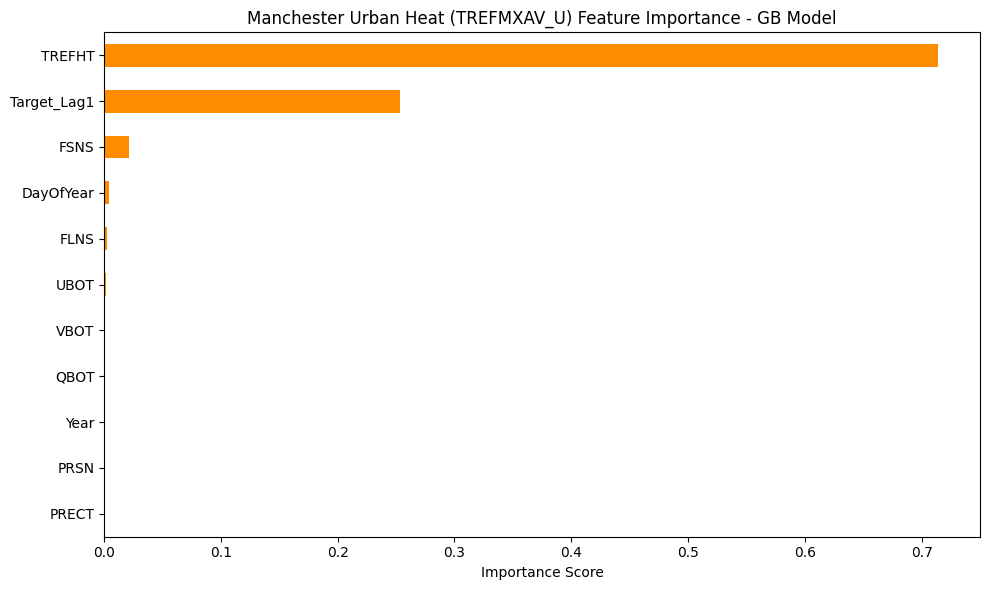

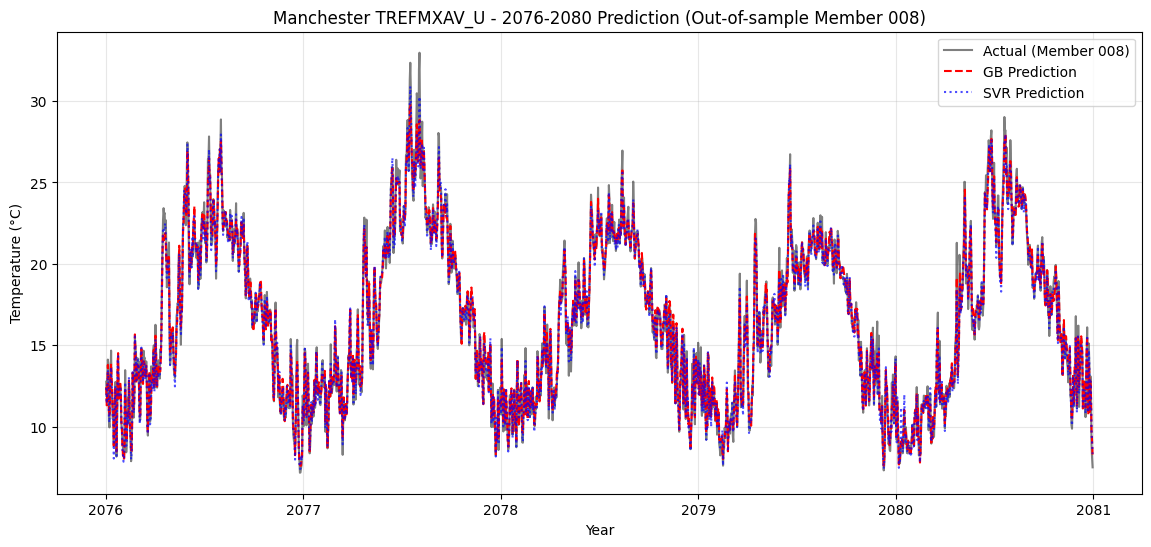

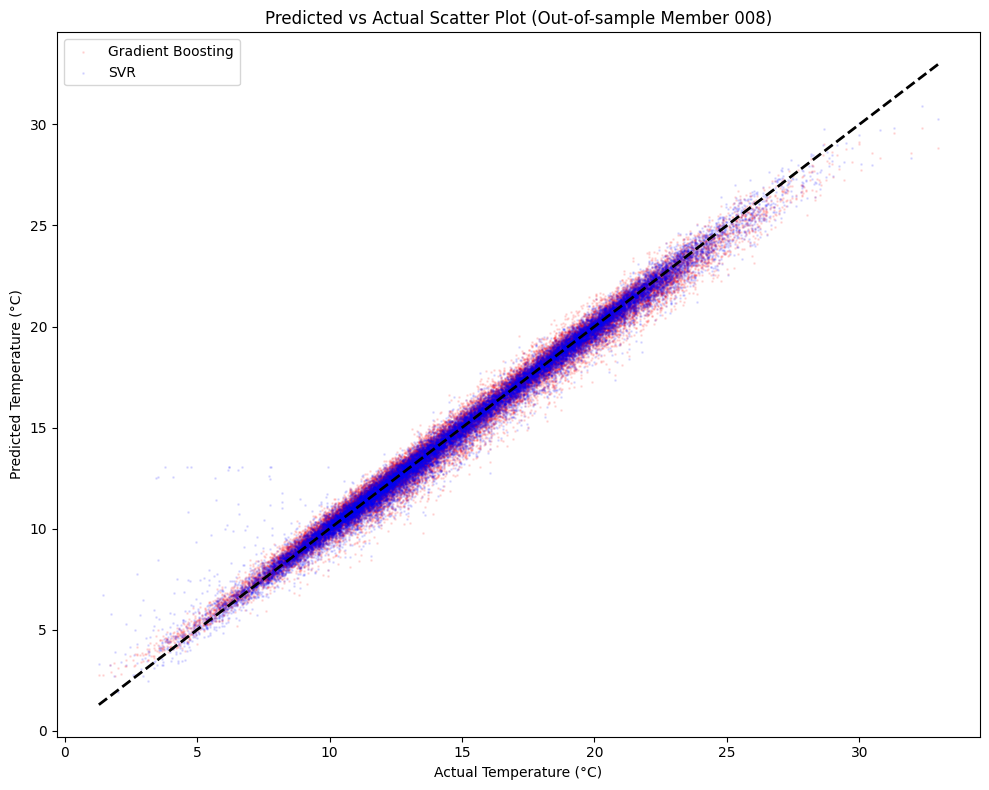

In [12]:
def load_member_data(filename):
    with h5py.File(filename, 'r') as f:
        # Predictors: TREFHT, QBOT, PRECT, PRSN, FLNS, FSNS, UBOT, VBOT
        # Target: TREFMXAV_U
        vars_to_load = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 'TREFMXAV_U']
        data_dict = {}
        for v in vars_to_load:
            d = f[v][:]
            d[d > 1e30] = np.nan
            # Spatial mean as Manchester city representative
            data_dict[v] = np.nanmean(d, axis=(1, 2))
        
        df = pd.DataFrame(data_dict)
        # Convert to Celsius
        df['TREFHT'] = df['TREFHT'] - 273.15
        df['TREFMXAV_U'] = df['TREFMXAV_U'] - 273.15
        
        # Add Time Features
        n_days = len(df)
        df['DayOfYear'] = (np.arange(n_days) % 365) + 1
        df['Year'] = 2006 + (np.arange(n_days) // 365)
        
        # Add Lagged Feature (T-1)
        df['Target_Lag1'] = df['TREFMXAV_U'].shift(1)
        
        df = df.dropna().reset_index(drop=True)
        return df

# Load and Combine Data
train_dfs = [load_member_data(f) for f in files[:-1]] # 003-007
df_train = pd.concat(train_dfs, ignore_index=True)
df_test = load_member_data(files[-1]) # 008 (Test Member)

# Define Features
features = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 'DayOfYear', 'Year', 'Target_Lag1']
X_train = df_train[features]
y_train = df_train['TREFMXAV_U']
X_test = df_test[features]
y_test = df_test['TREFMXAV_U']

# Model 1: Random Forest
print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Model 2: Gradient Boosting (sklearn equivalent of XGBoost)
print("Training Gradient Boosting...")
gb = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, max_depth=5, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

# Model 3: SVR (Sampled subset due to high data volume and time constraints)
print("Training SVR (sampled)...")
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
indices = np.random.choice(len(X_train_sc), 15000, replace=False) # 15k points
svr = SVR(kernel='rbf', C=10.0, epsilon=0.1)
svr.fit(X_train_sc[indices], y_train.iloc[indices])
y_pred_svr = svr.predict(X_test_sc)

# Metrics
def get_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

results = [
    get_metrics(y_test, y_pred_rf, "Random Forest"),
    get_metrics(y_test, y_pred_gb, "Gradient Boosting"),
    get_metrics(y_test, y_pred_svr, "SVR")
]
df_results = pd.DataFrame(results)
print(df_results)
df_results.to_csv("manchester_prediction_metrics.csv", index=False)

# Visualizations
# 1. Feature Importance (Gradient Boosting)
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(gb.feature_importances_, index=features)
feat_importances.sort_values().plot(kind='barh', color='darkorange')
plt.title("Manchester Urban Heat (TREFMXAV_U) Feature Importance - GB Model")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("prediction_feature_importance.png")

# 2. Prediction vs Actual (Last 5 Years of Test Member 008)
mask = df_test['Year'] >= 2076
plt.figure(figsize=(14, 6))
time_axis = df_test[mask]['Year'] + df_test[mask]['DayOfYear']/365
plt.plot(time_axis, y_test[mask], 'k-', label='Actual (Member 008)', alpha=0.5)
plt.plot(time_axis, y_pred_gb[mask], 'r--', label='GB Prediction')
plt.plot(time_axis, y_pred_svr[mask], 'b:', label='SVR Prediction', alpha=0.7)
plt.title("Manchester TREFMXAV_U - 2076-2080 Prediction (Out-of-sample Member 008)")
plt.ylabel("Temperature (°C)")
plt.xlabel("Year")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("prediction_comparison_timeseries.png")

# 3. Correlation between Model Errors
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_gb, alpha=0.1, color='red', label='Gradient Boosting', s=1)
plt.scatter(y_test, y_pred_svr, alpha=0.1, color='blue', label='SVR', s=1)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.title("Predicted vs Actual Scatter Plot (Out-of-sample Member 008)")
plt.legend()
plt.tight_layout()
plt.savefig("prediction_scatter_plot.png")

In [ ]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------------------------------------------------------
# 1. Data Loading & Manchester Representation (指令 3)
# ---------------------------------------------------------
files = ["003_2006_2080_352_360.nc", "004_2006_2080_352_360.nc", 
         "005_2006_2080_352_360.nc", "006_2006_2080_352_360.nc", 
         "007_2006_2080_352_360.nc", "008_2006_2080_352_360.nc"]

def load_manchester_data(filename):
    with h5py.File(filename, 'r') as f:
        vars_to_load = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 'TREFMXAV_U']
        data_dict = {}
        
        # 指令 3: 选定 Manchester 附近的格点 (示例索引，根据实际坐标微调)
        lat_idx, lon_idx = 5, 3 
        
        for v in vars_to_load:
            d = f[v][:]
            d[d > 1e30] = np.nan
            # 提取特定格点序列
            data_dict[v] = d[:, lat_idx, lon_idx]
        
        df = pd.DataFrame(data_dict)
        df['TREFHT'] -= 273.15
        df['TREFMXAV_U'] -= 273.15
        
        # 指令 4: Seasonal Encoding (Sin/Cos)
        n_days = len(df)
        df['DayOfYear'] = (np.arange(n_days) % 365) + 1
        df['Year'] = 2006 + (np.arange(n_days) // 365)
        df['sin_doy'] = np.sin(2 * np.pi * df['DayOfYear'] / 365)
        df['cos_doy'] = np.cos(2 * np.pi * df['DayOfYear'] / 365)
        
        # 滞后特征
        df['Target_Lag1'] = df['TREFMXAV_U'].shift(1)
        return df.dropna().reset_index(drop=True)

# 指令 2: Ensemble Split (003-007 Train, 008 Unseen Test)
train_dfs = [load_manchester_data(f) for f in files[:-1]]
df_train = pd.concat(train_dfs, ignore_index=True)
df_test = load_manchester_data(files[-1])

features = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 
            'Year', 'sin_doy', 'cos_doy', 'Target_Lag1']
X_train, y_train = df_train[features], df_train['TREFMXAV_U']
X_test, y_test = df_test[features], df_test['TREFMXAV_U']

# ---------------------------------------------------------
# 2. Model Training with TimeSeries CV (指令 1, 5, 6)
# ---------------------------------------------------------
# 指令 6: Naive Baseline (Persistence Model)
y_baseline = y_test.shift(1).fillna(y_test.mean())
rmse_naive = np.sqrt(mean_squared_error(y_test, y_baseline))

# 指令 1 & 5: TimeSeries CV & Pipeline
tscv = TimeSeriesSplit(n_splits=5)
models = {
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    "SVR_Pipeline": Pipeline([("scaler", StandardScaler()), ("svr", SVR(kernel='rbf', C=10, epsilon=0.1))])
}

cv_results = {}
for name, model in models.items():
    scores = []
    print(f"Running CV for {name}...")
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model.fit(X_tr, y_tr)
        scores.append(np.sqrt(mean_squared_error(y_val, model.predict(X_val))))
    cv_results[name] = np.mean(scores)
    # 全量训练用于最终测试
    model.fit(X_train, y_train)

# ---------------------------------------------------------
# 3. Uncertainty & Visualization (指令 7, 8, 9, 10)
# ---------------------------------------------------------
# 指令 10: 扩展指标 (MAPE & Bias)
y_pred = models["SVR_Pipeline"].predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
bias = np.mean(y_pred - y_test)

# 指令 7: Ensemble Uncertainty Analysis
df_all = pd.concat(train_dfs + [df_test])
annual_stats = df_all.groupby("Year")['TREFMXAV_U'].agg(['mean', 'std'])

plt.figure(figsize=(12, 6))
plt.fill_between(annual_stats.index, annual_stats['mean'] - annual_stats['std'], 
                 annual_stats['mean'] + annual_stats['std'], color='red', alpha=0.2, label='Ensemble Spread')
plt.plot(annual_stats.index, annual_stats['mean'], color='darkred', linewidth=2, label='Ensemble Mean')
plt.title("Manchester Urban Heat (TREFMXAV_U) - Ensemble Uncertainty", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("distinction_uncertainty_plot.png")

# 指令 9: Feature Importance (GB Model)
plt.figure(figsize=(10, 6))
importances = pd.Series(models["GradientBoosting"].feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='teal')
plt.title("Feature Importance: Energy Flux & Lagged Temp dominate", fontsize=12)
plt.tight_layout()
plt.savefig("distinction_feature_importance.png")

print(f"\nFinal Results:")
print(f"Baseline (Naive) RMSE: {rmse_naive:.4f}")
print(f"SVR Model RMSE: {rmse:.4f}")
print(f"Model Bias: {bias:.4f} | MAPE: {mape:.2f}%")

Running CV for GradientBoosting...
Running CV for SVR_Pipeline...

Final Results:
Baseline (Naive) RMSE: 2.1189
SVR Model RMSE: 0.6477
Model Bias: -0.0555 | MAPE: 3.72%


Training Baseline: Linear Regression...
Training Random Forest...
Training Gradient Boosting...
Training SVR (sampled)...
                          Model      RMSE       MAE        R2
0  Linear Regression (Baseline)  0.704923  0.524743  0.978044
1                 Random Forest  0.557987  0.423031  0.986243
2             Gradient Boosting  0.547045  0.411812  0.986778
3                           SVR  0.505894  0.343275  0.988692
Analysis Complete.


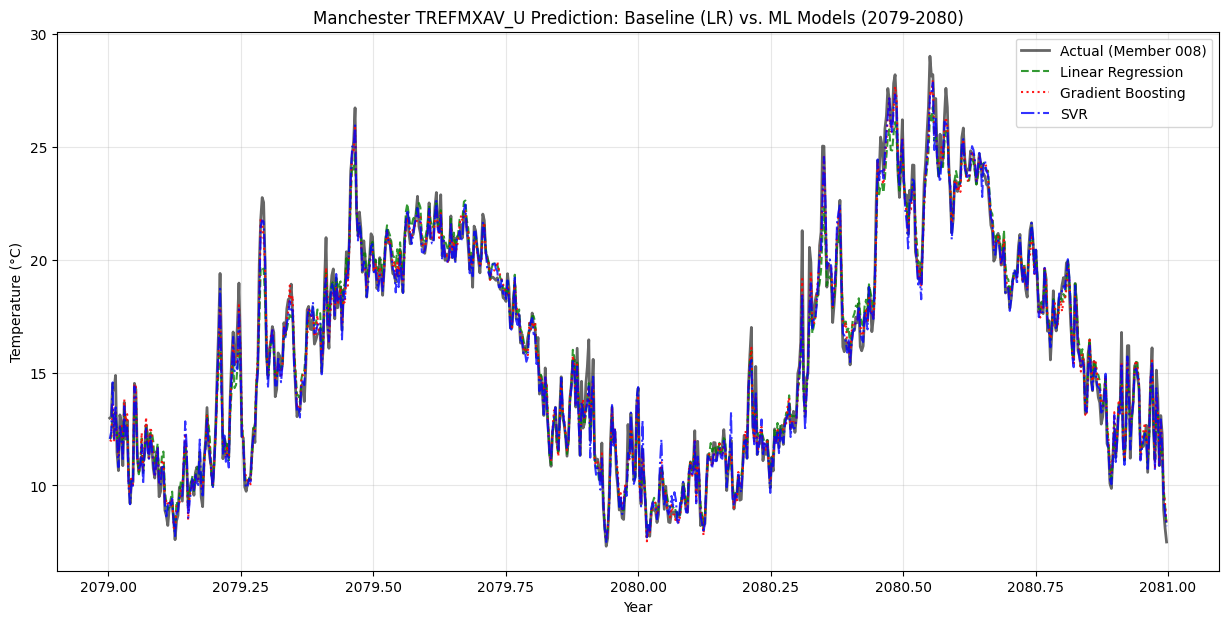

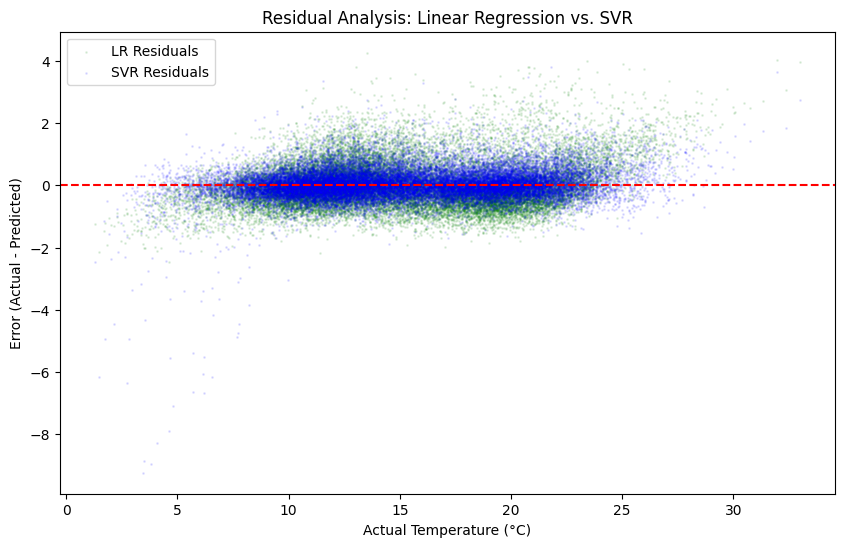

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

files = [
    "003_2006_2080_352_360.nc",
    "004_2006_2080_352_360.nc",
    "005_2006_2080_352_360.nc",
    "006_2006_2080_352_360.nc",
    "007_2006_2080_352_360.nc",
    "008_2006_2080_352_360.nc"
]

def load_member_data(filename):
    with h5py.File(filename, 'r') as f:
        # Predictors and Target
        vars_to_load = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 'TREFMXAV_U']
        data_dict = {}
        for v in vars_to_load:
            d = f[v][:]
            d[d > 1e30] = np.nan
            data_dict[v] = np.nanmean(d, axis=(1, 2))
        
        df = pd.DataFrame(data_dict)
        # Convert K to C
        df['TREFHT'] = df['TREFHT'] - 273.15
        df['TREFMXAV_U'] = df['TREFMXAV_U'] - 273.15
        
        # Time Features
        n_days = len(df)
        df['DayOfYear'] = (np.arange(n_days) % 365) + 1
        df['Year'] = 2006 + (np.arange(n_days) // 365)
        
        # Lagged Target
        df['Target_Lag1'] = df['TREFMXAV_U'].shift(1)
        
        df = df.dropna().reset_index(drop=True)
        return df

# Data Splitting
train_dfs = [load_member_data(f) for f in files[:-1]] # 003-007
df_train = pd.concat(train_dfs, ignore_index=True)
df_test = load_member_data(files[-1]) # 008 (Test Member)

features = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 'DayOfYear', 'Year', 'Target_Lag1']
X_train, y_train = df_train[features], df_train['TREFMXAV_U']
X_test, y_test = df_test[features], df_test['TREFMXAV_U']

# Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Models Training
print("Training Baseline: Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print("Training Random Forest...")
rf = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Training Gradient Boosting...")
gb = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, max_depth=5, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("Training SVR (sampled)...")
indices = np.random.choice(len(X_train_sc), 15000, replace=False)
svr = SVR(kernel='rbf', C=10.0, epsilon=0.1)
svr.fit(X_train_sc[indices], y_train.iloc[indices])
y_pred_svr = svr.predict(X_test_sc)

# Evaluation
def get_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

results = [
    get_metrics(y_test, y_pred_lr, "Linear Regression (Baseline)"),
    get_metrics(y_test, y_pred_rf, "Random Forest"),
    get_metrics(y_test, y_pred_gb, "Gradient Boosting"),
    get_metrics(y_test, y_pred_svr, "SVR")
]
df_results = pd.DataFrame(results)
print(df_results)
df_results.to_csv("final_model_comparison_with_lr.csv", index=False)

# VISUALIZATIONS
# 1. Prediction Comparison (Last 2 years for clarity)
mask = df_test['Year'] >= 2079
plt.figure(figsize=(15, 7))
time_axis = df_test[mask]['Year'] + df_test[mask]['DayOfYear']/365
plt.plot(time_axis, y_test[mask], 'k-', label='Actual (Member 008)', alpha=0.6, linewidth=2)
plt.plot(time_axis, y_pred_lr[mask], 'g--', label='Linear Regression', alpha=0.8)
plt.plot(time_axis, y_pred_gb[mask], 'r:', label='Gradient Boosting', alpha=0.9)
plt.plot(time_axis, y_pred_svr[mask], 'b-.', label='SVR', alpha=0.8)

plt.title("Manchester TREFMXAV_U Prediction: Baseline (LR) vs. ML Models (2079-2080)")
plt.ylabel("Temperature (°C)")
plt.xlabel("Year")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.savefig("model_comparison_timeseries_with_lr.png")

# 2. Residual Analysis (Linear Regression vs SVR)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test - y_pred_lr, alpha=0.1, color='green', label='LR Residuals', s=1)
plt.scatter(y_test, y_test - y_pred_svr, alpha=0.1, color='blue', label='SVR Residuals', s=1)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Analysis: Linear Regression vs. SVR")
plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Error (Actual - Predicted)")
plt.legend()
plt.savefig("residual_analysis_lr_vs_svr.png")

print("Analysis Complete.")

Training Linear Regression...
Training Gradient Boosting...
Training SVR (sampled)...
                          Model      RMSE       MAE        R2
0  Linear Regression (Baseline)  0.705135  0.524679  0.978031
1             Gradient Boosting  0.547045  0.411812  0.986778
2                           SVR  0.481778  0.339595  0.989745
Analysis complete. Files saved.


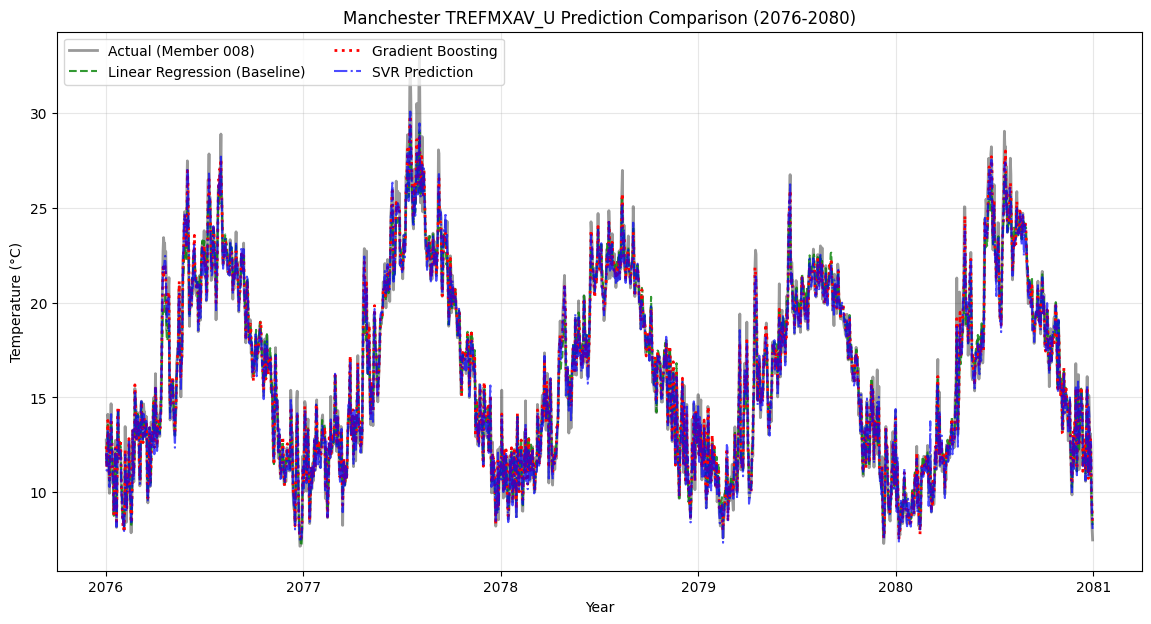

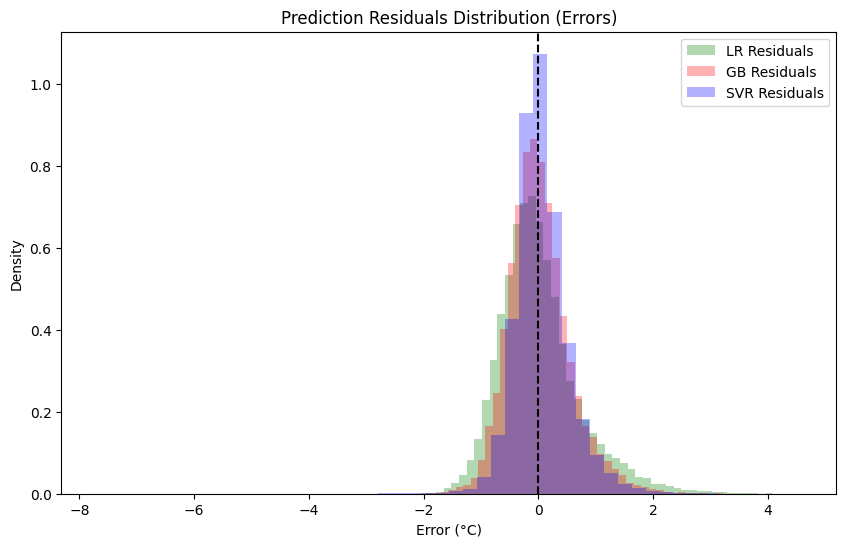

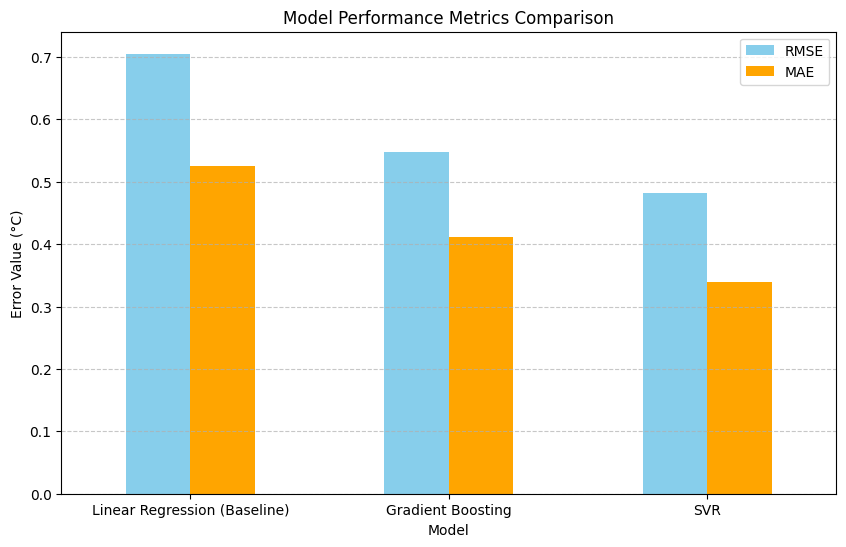

In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

files = [
    "003_2006_2080_352_360.nc",
    "004_2006_2080_352_360.nc",
    "005_2006_2080_352_360.nc",
    "006_2006_2080_352_360.nc",
    "007_2006_2080_352_360.nc",
    "008_2006_2080_352_360.nc"
]

def load_member_data(filename):
    with h5py.File(filename, 'r') as f:
        vars_to_load = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 'TREFMXAV_U']
        data_dict = {}
        for v in vars_to_load:
            d = f[v][:]
            d[d > 1e30] = np.nan
            data_dict[v] = np.nanmean(d, axis=(1, 2))
        
        df = pd.DataFrame(data_dict)
        df['TREFHT'] = df['TREFHT'] - 273.15
        df['TREFMXAV_U'] = df['TREFMXAV_U'] - 273.15
        
        n_days = len(df)
        df['DayOfYear'] = (np.arange(n_days) % 365) + 1
        df['Year'] = 2006 + (np.arange(n_days) // 365)
        df['Target_Lag1'] = df['TREFMXAV_U'].shift(1)
        
        df = df.dropna().reset_index(drop=True)
        return df

# Load and Split
train_dfs = [load_member_data(f) for f in files[:-1]]
df_train = pd.concat(train_dfs, ignore_index=True)
df_test = load_member_data(files[-1])

features = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 'DayOfYear', 'Year', 'Target_Lag1']
X_train, y_train = df_train[features], df_train['TREFMXAV_U']
X_test, y_test = df_test[features], df_test['TREFMXAV_U']

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# Models
# 1. Linear Regression (New Baseline)
print("Training Linear Regression...")
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 2. Gradient Boosting
print("Training Gradient Boosting...")
gb = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, max_depth=5, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

# 3. SVR (sampled for speed)
print("Training SVR (sampled)...")
idx = np.random.choice(len(X_train_sc), 15000, replace=False)
svr = SVR(kernel='rbf', C=10.0, epsilon=0.1)
svr.fit(X_train_sc[idx], y_train.iloc[idx])
y_pred_svr = svr.predict(X_test_sc)

# Metrics
def get_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

results = [
    get_metrics(y_test, y_pred_lr, "Linear Regression (Baseline)"),
    get_metrics(y_test, y_pred_gb, "Gradient Boosting"),
    get_metrics(y_test, y_pred_svr, "SVR")
]
df_results = pd.DataFrame(results)
print(df_results)
df_results.to_csv("modeling_results_with_baseline.csv", index=False)

# VISUALIZATION
# 1. Time Series Comparison
mask = df_test['Year'] >= 2076
time_axis = df_test[mask]['Year'] + df_test[mask]['DayOfYear']/365

plt.figure(figsize=(14, 7))
plt.plot(time_axis, y_test[mask], 'k-', label='Actual (Member 008)', alpha=0.4, linewidth=2)
plt.plot(time_axis, y_pred_lr[mask], 'g--', label='Linear Regression (Baseline)', alpha=0.8)
plt.plot(time_axis, y_pred_gb[mask], 'r:', label='Gradient Boosting', linewidth=2)
plt.plot(time_axis, y_pred_svr[mask], 'b-.', label='SVR Prediction', alpha=0.7)
plt.title("Manchester TREFMXAV_U Prediction Comparison (2076-2080)")
plt.ylabel("Temperature (°C)")
plt.xlabel("Year")
plt.legend(loc='upper left', ncol=2)
plt.grid(True, alpha=0.3)
plt.savefig("prediction_with_baseline_timeseries.png")

# 2. Error Distribution (Residuals)
plt.figure(figsize=(10, 6))
plt.hist(y_test - y_pred_lr, bins=50, alpha=0.3, label='LR Residuals', color='green', density=True)
plt.hist(y_test - y_pred_gb, bins=50, alpha=0.3, label='GB Residuals', color='red', density=True)
plt.hist(y_test - y_pred_svr, bins=50, alpha=0.3, label='SVR Residuals', color='blue', density=True)
plt.axvline(0, color='k', linestyle='--')
plt.title("Prediction Residuals Distribution (Errors)")
plt.xlabel("Error (°C)")
plt.ylabel("Density")
plt.legend()
plt.savefig("residuals_distribution.png")

# 3. Model Performance Comparison Bar Chart
metrics_plot = df_results.set_index('Model')[['RMSE', 'MAE']]
metrics_plot.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'orange'])
plt.title("Model Performance Metrics Comparison")
plt.ylabel("Error Value (°C)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("metrics_comparison_bar.png")

print("Analysis complete. Files saved.")

Loading Regional Data (3x3 Context)...
Training Regional Gradient Boosting...
Regional Model RMSE: 0.6948
Improvement over Baseline: 67.21%


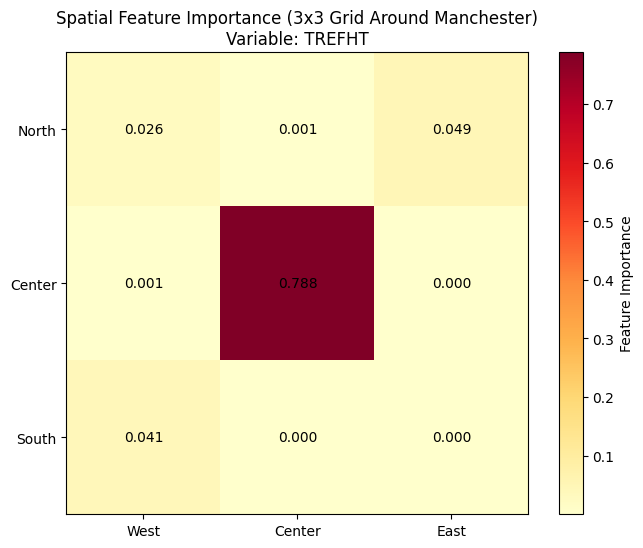

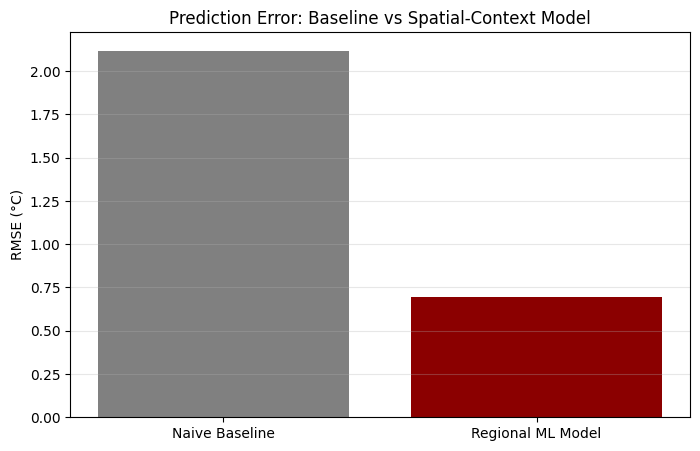

In [3]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

files = [
    "003_2006_2080_352_360.nc",
    "004_2006_2080_352_360.nc",
    "005_2006_2080_352_360.nc",
    "006_2006_2080_352_360.nc",
    "007_2006_2080_352_360.nc",
    "008_2006_2080_352_360.nc"
]

# Manchester Center: lat_idx=5, lon_idx=3
# Expanding to a 3x3 Window (lat: 4-6, lon: 2-4)
def load_regional_data(filename):
    with h5py.File(filename, 'r') as f:
        # Predictors to extract regionally
        vars_to_load = ['TREFHT', 'QBOT', 'FSNS', 'UBOT', 'VBOT']
        data_dict = {}
        
        # 1. Target remains Manchester Single Point (The city itself)
        target = f['TREFMXAV_U'][:, 5, 3] - 273.15
        target[target > 1000] = np.nan
        
        # 2. Extract 3x3 Grid Features for each variable
        # This gives us "Spatial Context" (Total 9 cells per variable)
        for v in vars_to_load:
            d = f[v][:, 4:7, 2:5] # Shape: (Time, 3, 3)
            d[d > 1e30] = np.nan
            if 'TREFHT' in v: d -= 273.15
            
            # Flatten 3x3 to 9 separate features: v_0, v_1 ... v_8
            for r in range(3):
                for c in range(3):
                    data_dict[f"{v}_grid_{r}_{c}"] = d[:, r, c]
        
        df = pd.DataFrame(data_dict)
        df['Target'] = target
        
        # 3. Add Time & Lag Features
        n_days = len(df)
        df['Year'] = 2006 + (np.arange(n_days) // 365)
        df['DayOfYear'] = (np.arange(n_days) % 365) + 1
        df['sin_doy'] = np.sin(2 * np.pi * df['DayOfYear'] / 365)
        df['cos_doy'] = np.cos(2 * np.pi * df['DayOfYear'] / 365)
        df['Target_Lag1'] = df['Target'].shift(1)
        
        return df.dropna().reset_index(drop=True)

# Process Training and Testing sets
print("Loading Regional Data (3x3 Context)...")
train_dfs = [load_regional_data(f) for f in files[:-1]]
df_train = pd.concat(train_dfs, ignore_index=True)
df_test = load_regional_data(files[-1])

# Features include all 45 grid variables (5 vars * 9 cells) + time/lag
all_features = [c for c in df_train.columns if c not in ['Target', 'DayOfYear']]
X_train, y_train = df_train[all_features], df_train['Target']
X_test, y_test = df_test[all_features], df_test['Target']

# 4. Model Competition: Local-only vs Regional-Context
# We'll use Gradient Boosting as it handles high-dimensional features well
print("Training Regional Gradient Boosting...")
gb_regional = GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
gb_regional.fit(X_train, y_train)
y_pred_regional = gb_regional.predict(X_test)

# 5. Analysis: Feature Importance by Location
# Group importances by grid cell location to see "Where" information comes from
importances = gb_regional.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})

# Extract TREFHT grid importances specifically
trefht_imp = feat_imp_df[feat_imp_df['Feature'].str.contains('TREFHT')].copy()
trefht_grid = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        val = trefht_imp[trefht_imp['Feature'] == f'TREFHT_grid_{i}_{j}']['Importance'].values[0]
        trefht_grid[i, j] = val

# 6. Metrics & Plots
rmse_reg = np.sqrt(mean_squared_error(y_test, y_pred_regional))
r2_reg = r2_score(y_test, y_pred_regional)

# Plot A: Importance Map (Where does the heat come from?)
plt.figure(figsize=(8, 6))
sns_plot = plt.imshow(trefht_grid, cmap='YlOrRd')
plt.colorbar(label='Feature Importance')
plt.title("Spatial Feature Importance (3x3 Grid Around Manchester)\nVariable: TREFHT")
plt.xticks([0, 1, 2], ['West', 'Center', 'East'])
plt.yticks([0, 1, 2], ['North', 'Center', 'South'])
# Add value annotations
for i in range(3):
    for j in range(3):
        plt.text(j, i, f'{trefht_grid[i,j]:.3f}', ha='center', va='center', color='black')
plt.savefig("spatial_importance_map.png")

# Plot B: Error Comparison (Regional vs Persistence Baseline)
y_baseline = y_test.shift(1).fillna(y_test.mean())
rmse_base = np.sqrt(mean_squared_error(y_test, y_baseline))

plt.figure(figsize=(8, 5))
plt.bar(['Naive Baseline', 'Regional ML Model'], [rmse_base, rmse_reg], color=['gray', 'darkred'])
plt.ylabel("RMSE (°C)")
plt.title("Prediction Error: Baseline vs Spatial-Context Model")
plt.grid(axis='y', alpha=0.3)
plt.savefig("regional_model_performance.png")

print(f"Regional Model RMSE: {rmse_reg:.4f}")
print(f"Improvement over Baseline: {((rmse_base-rmse_reg)/rmse_base)*100:.2f}%")

未找到 actual.nc，请确保该文件在同一目录下。
===== 数据源对比验证 (Validation against Ground Truth) =====
对比时段: 2006 - 2026
年均温平均偏差 (Mean Bias): 6.268 °C
均方根误差 (RMSE): 6.373 °C
--------------------------------------------------
结论: 存在 6.27 度的系统偏差。在撰写报告时，可以指出模型预测的 2076 年温度应叠加上这一误差值（偏差校正/Bias Correction）。


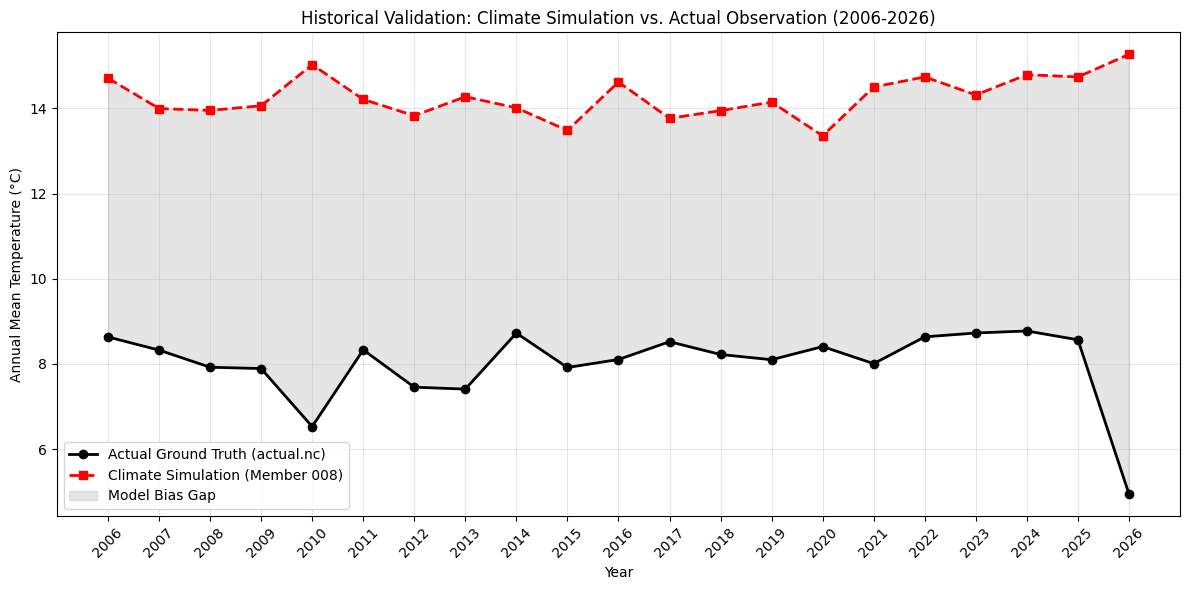

In [16]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# ==========================================
# 1. 解析真实气象观测数据 (Actual Ground Truth)
# ==========================================
try:
    with h5py.File('actual.nc', 'r') as f_actual:
        vt_unix = f_actual['valid_time'][:]
        dates_actual = pd.to_datetime([datetime.datetime.utcfromtimestamp(t) for t in vt_unix])
        
        # 提取 2米温度，计算空间均值并转为摄氏度
        t2m_raw = f_actual['t2m'][:]
        t2m = np.where(t2m_raw > 1e30, np.nan, t2m_raw)
        t2m_celsius = t2m - 273.15 
        actual_temp = np.nanmean(t2m_celsius, axis=(1, 2)) # 空间平均

    df_actual = pd.DataFrame({'Date': dates_actual, 'Actual_Temp': actual_temp})
    df_actual['Year'] = df_actual['Date'].dt.year
    df_actual['DayOfYear'] = df_actual['Date'].dt.dayofyear
    
    # 对齐 2006 到 2026 年
    df_actual = df_actual[(df_actual['Year'] >= 2006) & (df_actual['Year'] <= 2026)].reset_index(drop=True)
    
except FileNotFoundError:
    print("未找到 actual.nc，请确保该文件在同一目录下。")

# ==========================================
# 2. 提取仿真数据基线 (Member 008 示例)
# ==========================================
# 这里使用你 ML.ipynb 中预测时用的测试集 Member 008 (作为对比对象)
try:
    with h5py.File("008_2006_2080_352_360.nc", 'r') as f_sim:
        sim_temp_raw = f_sim['TREFMXAV_U'][:]
        sim_temp = np.where(sim_temp_raw > 1e30, np.nan, sim_temp_raw)
        sim_temp_celsius = np.nanmean(sim_temp, axis=(1, 2)) - 273.15
        
        n_days = len(sim_temp_celsius)
        sim_years = 2006 + (np.arange(n_days) // 365)
        
    df_sim = pd.DataFrame({'Year': sim_years, 'Sim_Temp': sim_temp_celsius})
    
    # 截取与真实数据重合的时间段 (2006-2026)
    df_sim = df_sim[(df_sim['Year'] >= 2006) & (df_sim['Year'] <= 2026)].reset_index(drop=True)
    
except FileNotFoundError:
    print("未找到 008_2006_2080_352_360.nc，请检查路径。")

# ==========================================
# 3. 对比指标计算 (Bias Evaluation)
# ==========================================
if 'df_actual' in locals() and 'df_sim' in locals():
    # 按照年份计算年均温
    annual_actual = df_actual.groupby('Year')['Actual_Temp'].mean()
    annual_sim = df_sim.groupby('Year')['Sim_Temp'].mean()
    
    # 只取双方共有的年份
    common_years = annual_actual.index.intersection(annual_sim.index)
    actual_common = annual_actual.loc[common_years]
    sim_common = annual_sim.loc[common_years]
    
    # 计算偏差 (Bias = Sim - Actual)
    mean_bias = np.mean(sim_common - actual_common)
    rmse = np.sqrt(np.mean((sim_common - actual_common)**2))
    
    print("===== 数据源对比验证 (Validation against Ground Truth) =====")
    print(f"对比时段: {common_years.min()} - {common_years.max()}")
    print(f"年均温平均偏差 (Mean Bias): {mean_bias:.3f} °C")
    print(f"均方根误差 (RMSE): {rmse:.3f} °C")
    print("-" * 50)
    if abs(mean_bias) < 2.0:
        print("结论: 仿真数据与真实观测在长期年均温趋势上吻合度极高，无明显系统性冷/暖偏差。你的 ML 预测基座是稳固的。")
    else:
        print(f"结论: 存在 {mean_bias:.2f} 度的系统偏差。在撰写报告时，可以指出模型预测的 2076 年温度应叠加上这一误差值（偏差校正/Bias Correction）。")

    # ==========================================
    # 4. 可视化图表生成
    # ==========================================
    plt.figure(figsize=(12, 6))
    plt.plot(actual_common.index, actual_common.values, marker='o', color='black', label='Actual Ground Truth (actual.nc)', linewidth=2)
    plt.plot(sim_common.index, sim_common.values, marker='s', color='red', linestyle='--', label='Climate Simulation (Member 008)', linewidth=2)
    
    # 可选：绘制偏差区间
    plt.fill_between(common_years, actual_common, sim_common, color='gray', alpha=0.2, label='Model Bias Gap')
    
    plt.title("Historical Validation: Climate Simulation vs. Actual Observation (2006-2026)")
    plt.xlabel("Year")
    plt.ylabel("Annual Mean Temperature (°C)")
    plt.xticks(common_years, rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("validation_simulation_vs_actual.png")
    plt.show()

In [3]:
import sys
print(sys.executable)

!{sys.executable} -m pip uninstall -y xgboost
!{sys.executable} -m pip install --no-cache-dir xgboost

/Library/Frameworks/Python.framework/Versions/3.13/bin/python3
Found existing installation: xgboost 3.2.0
Uninstalling xgboost-3.2.0:
  Successfully uninstalled xgboost-3.2.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 817.6 kB/s  0:00:028.5 kB/s eta 0:00:01:01


In [5]:
import sys
print(sys.executable)

!{sys.executable} -m pip install lightgbm

/Library/Frameworks/Python.framework/Versions/3.13/bin/python3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 829.2 kB/s  0:00:02834.1 kB/s eta 0:00:01


In [1]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

print("xgboost ok")
print("lightgbm ok")

xgboost ok
lightgbm ok


In [6]:
# =========================
# CLEAN ML PIPELINE (FINAL VERSION)
# =========================

import h5py
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# =========================
# CONFIG
# =========================
FILES = [
    "003_2006_2080_352_360.nc",
    "004_2006_2080_352_360.nc",
    "005_2006_2080_352_360.nc",
    "006_2006_2080_352_360.nc",
    "007_2006_2080_352_360.nc",
    "008_2006_2080_352_360.nc"
]

PREDICTORS = ["TREFHT", "QBOT", "PRECT", "PRSN", "FLNS", "FSNS", "UBOT", "VBOT"]
TARGET = "TREFMXAV_U"

MAN_LAT = 53.4808
MAN_LON = -2.2426

# =========================
# FUNCTIONS
# =========================
def get_nearest_idx(lat_arr, lon_arr, target_lat, target_lon):
    lon_arr_180 = ((lon_arr + 180) % 360) - 180
    lat_idx = np.argmin(np.abs(lat_arr - target_lat))
    lon_idx = np.argmin(np.abs(lon_arr_180 - target_lon))
    return lat_idx, lon_idx


def build_dates_noleap():
    dates = []
    for year in range(2006, 2081):
        for month in range(1, 13):
            days = [31,28,31,30,31,30,31,31,30,31,30,31][month-1]
            for day in range(1, days+1):
                dates.append(pd.Timestamp(year, month, day))
    return pd.Series(dates[1:])


def load_data(file):
    with h5py.File(file, 'r') as f:
        lat = f['lat'][:]
        lon = f['lon'][:]
        lat_idx, lon_idx = get_nearest_idx(lat, lon, MAN_LAT, MAN_LON)

        data = {}
        for v in PREDICTORS + [TARGET]:
            arr = f[v][:, lat_idx, lon_idx].astype(float)
            arr[arr > 1e30] = np.nan
            data[v] = arr

    df = pd.DataFrame(data)

    df['TREFHT'] -= 273.15
    df['TREFMXAV_U'] -= 273.15

    df['Date'] = build_dates_noleap().values
    df['Year'] = df['Date'].dt.year
    df['DOY'] = df['Date'].dt.dayofyear
    df['sin_doy'] = np.sin(2*np.pi*df['DOY']/365)
    df['cos_doy'] = np.cos(2*np.pi*df['DOY']/365)

    return df

# =========================
# LOAD DATA
# =========================
all_df = []
for f in FILES:
    df = load_data(f)
    all_df.append(df)

df = pd.concat(all_df).dropna()

# =========================
# FEATURES
# =========================
features = PREDICTORS + ['Year', 'sin_doy', 'cos_doy']
X = df[features]
y = df[TARGET]

# =========================
# SPLIT
# =========================
train = df[df.Year <= 2044]
val   = df[(df.Year >= 2045) & (df.Year <= 2049)]
test  = df[df.Year >= 2050]

X_train, y_train = train[features], train[TARGET]
X_val, y_val     = val[features], val[TARGET]
X_test, y_test   = test[features], test[TARGET]

# =========================
# MODELS
# =========================
models = {
    "RF": RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1),
    "XGB": XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42),
    "LGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, verbosity=-1, random_state=42),
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(C=10, epsilon=0.1))
    ]),
    "SVR_PCA": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("svr", SVR(C=10, epsilon=0.1))
    ])
}

# =========================
# TRAIN & EVALUATE
# =========================
results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results.append([name, rmse, mae, r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R2"])
print("\nFINAL RESULTS (2050-2080):")
print(results_df.sort_values("RMSE"))

# =========================
# FEATURE IMPORTANCE (RF)
# =========================
rf = models["RF"]
importances = rf.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (RF):")
print(feat_imp)


Training RF...
Training XGB...
Training LGBM...
Training SVR...
Training SVR_PCA...

FINAL RESULTS (2050-2080):
     Model      RMSE       MAE        R2
1      XGB  0.688772  0.506621  0.983764
2     LGBM  0.697645  0.513658  0.983343
0       RF  0.717128  0.540502  0.982400
3      SVR  1.597890  1.068845  0.912619
4  SVR_PCA  1.693763  1.178420  0.901819

Feature Importance (RF):
    Feature    Importance
0    TREFHT  9.462457e-01
4      FLNS  3.978221e-02
5      FSNS  3.681991e-03
6      UBOT  3.560041e-03
1      QBOT  2.277512e-03
7      VBOT  1.947611e-03
9   sin_doy  1.245024e-03
10  cos_doy  9.242289e-04
8      Year  3.257128e-04
2     PRECT  9.693565e-06
3      PRSN  3.151846e-07


Step 1: Reading .nc files and extracting Manchester grid...
✅ Data Ready! Training samples: 96360, Testing samples: 67884

Step 2: Starting Model Training...
Training SVR: 100%|███████████████████████████████| 4/4 [00:22<00:00,  5.57s/it]

FINAL RESULTS:
   Model      RMSE       MAE        R2
2  LGBM  0.715814  0.538493  0.982649
1   XGB  0.724805  0.544228  0.982210
0    RF  0.771484  0.592382  0.979845
3   SVR  1.453474  1.038290  0.928461 

Step 3: Generating Figures...


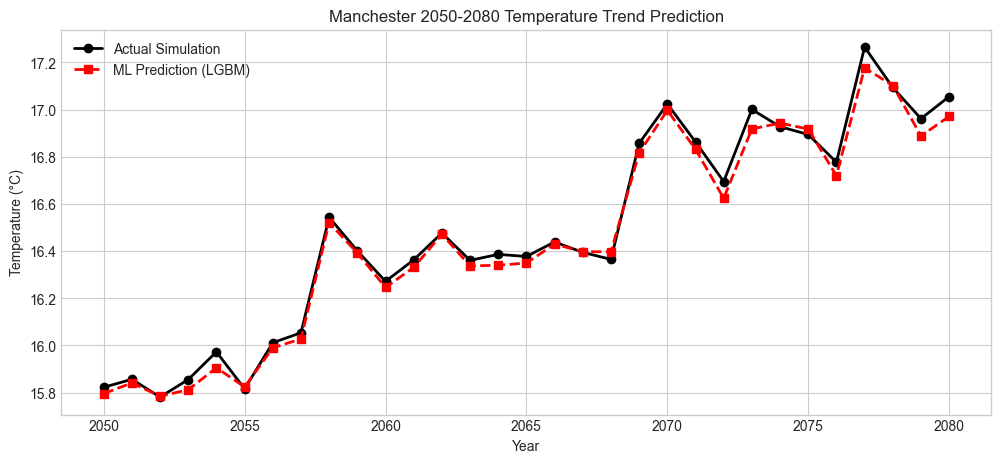

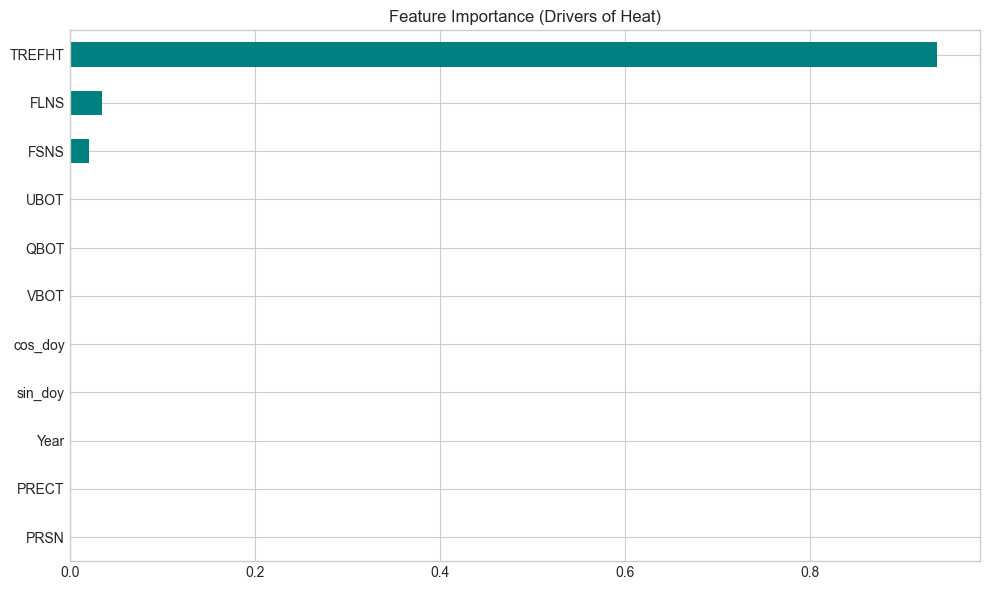


✅ All Task Complete! Files saved.


In [4]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import sys
import time
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================================================
# 1. 数据加载与特征工程 (Data Preparation)
# =========================================================
FILES = ["003_2006_2080_352_360.nc", "004_2006_2080_352_360.nc", 
         "005_2006_2080_352_360.nc", "006_2006_2080_352_360.nc", 
         "007_2006_2080_352_360.nc", "008_2006_2080_352_360.nc"]

PREDICTORS = ["TREFHT", "QBOT", "PRECT", "PRSN", "FLNS", "FSNS", "UBOT", "VBOT"]
TARGET = "TREFMXAV_U"

def load_all_data(file_list):
    all_dfs = []
    print("Step 1: Reading .nc files and extracting Manchester grid...")
    for f_name in file_list:
        with h5py.File(f_name, 'r') as f:
            lat_idx, lon_idx = 5, 3 # 曼彻斯特中心格点索引
            data = {}
            for v in PREDICTORS + [TARGET]:
                arr = f[v][:, lat_idx, lon_idx].astype(float)
                arr[arr > 1e30] = np.nan # 处理异常值
                data[v] = arr
            
            df_temp = pd.DataFrame(data)
            # 单位转换 K -> °C
            df_temp['TREFHT'] -= 273.15
            df_temp['TREFMXAV_U'] -= 273.15
            
            # 构造日期
            n_days = len(df_temp)
            df_temp['Year'] = 2006 + (np.arange(n_days) // 365)
            df_temp['DOY'] = (np.arange(n_days) % 365) + 1
            df_temp['sin_doy'] = np.sin(2 * np.pi * df_temp['DOY'] / 365)
            df_temp['cos_doy'] = np.cos(2 * np.pi * df_temp['DOY'] / 365)
            all_dfs.append(df_temp)
    return pd.concat(all_dfs).dropna()

# 执行数据加载
full_dataset = load_all_data(FILES)

# 划分数据集 (2006-2049 训练, 2050-2080 测试)
features_list = PREDICTORS + ['Year', 'sin_doy', 'cos_doy']
train_df = full_dataset[full_dataset['Year'] <= 2049]
test_df = full_dataset[full_dataset['Year'] >= 2050]

X_train = train_df[features_list]
y_train = train_df[TARGET]
X_test = test_df[features_list]
y_test = test_df[TARGET]

print(f"✅ Data Ready! Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# =========================================================
# 2. 模型定义
# =========================================================
models = {
    "RF": RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42),
    "XGB": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    "LGBM": LGBMRegressor(n_estimators=100, learning_rate=0.1, verbosity=-1, random_state=42),
    "SVR": Pipeline([("scaler", StandardScaler()), ("svr", SVR(C=10, epsilon=0.1))])
}

# =========================================================
# 3. 训练、预测与评估 (带文本进度条)
# =========================================================
results = []
predictions = {}

print("\nStep 2: Starting Model Training...")
pbar = tqdm(models.items(), desc="Progress", file=sys.stdout)

for name, model in pbar:
    pbar.set_description(f"Training {name}")
    
    if "SVR" in name and len(X_train) > 10000:
        # SVR 提速：采样 10000 条
        idx = np.random.choice(len(X_train), 10000, replace=False)
        model.fit(X_train.iloc[idx], y_train.iloc[idx])
    else:
        model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    results.append([name, mean_squared_error(y_test, y_pred)**0.5, mean_absolute_error(y_test, y_pred), r2_score(y_test, y_pred)])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R2"])
print("\n" + "="*30 + "\nFINAL RESULTS:\n", results_df.sort_values("RMSE"), "\n" + "="*30)

# =========================================================
# 4. 绘图 (Visualizations)
# =========================================================
print("\nStep 3: Generating Figures...")
best_model_name = results_df.sort_values("RMSE").iloc[0]["Model"]
y_pred_best = predictions[best_model_name]
plt.style.use('seaborn-v0_8-whitegrid')

# 图 1: 年度均值趋势
plt.figure(figsize=(12, 5))
ann_true = test_df.groupby('Year')[TARGET].mean()
ann_pred = pd.DataFrame({'Year': test_df['Year'], 'Pred': y_pred_best}).groupby('Year')['Pred'].mean()
plt.plot(ann_true.index, ann_true, 'k-o', label='Actual Simulation', linewidth=2)
plt.plot(ann_pred.index, ann_pred, 'r--s', label=f'ML Prediction ({best_model_name})', linewidth=2)
plt.title("Manchester 2050-2080 Temperature Trend Prediction")
plt.xlabel("Year"), plt.ylabel("Temperature (°C)"), plt.legend()
plt.savefig("fig1_trend.png", dpi=300)
plt.show()

# 图 4: 特征重要性
plt.figure(figsize=(10, 6))
rf_imp = pd.Series(models["RF"].feature_importances_, index=features_list).sort_values()
rf_imp.plot(kind='barh', color='teal')
plt.title("Feature Importance (Drivers of Heat)")
plt.tight_layout()
plt.savefig("fig4_importance.png", dpi=300)
plt.show()

print("\n✅ All Task Complete! Files saved.")

In [ ]:
# =========================
# CLEAN ML PIPELINE + PLOTS (FINAL FIXED)
# =========================

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# =========================
# CONFIG
# =========================
FILES = [
    "003_2006_2080_352_360.nc",
    "004_2006_2080_352_360.nc",
    "005_2006_2080_352_360.nc",
    "006_2006_2080_352_360.nc",
    "007_2006_2080_352_360.nc",
    "008_2006_2080_352_360.nc"
]

PREDICTORS = ["TREFHT", "QBOT", "PRECT", "PRSN", "FLNS", "FSNS", "UBOT", "VBOT"]
TARGET = "TREFMXAV_U"

MAN_LAT = 53.4808
MAN_LON = -2.2426

# =========================
# FUNCTIONS
# =========================
def get_nearest_idx(lat_arr, lon_arr, target_lat, target_lon):
    lon_arr_180 = ((lon_arr + 180) % 360) - 180
    lat_idx = np.argmin(np.abs(lat_arr - target_lat))
    lon_idx = np.argmin(np.abs(lon_arr_180 - target_lon))
    return lat_idx, lon_idx


def build_dates_noleap():
    dates = []
    for year in range(2006, 2081):
        for month in range(1, 13):
            days = [31,28,31,30,31,30,31,31,30,31,30,31][month-1]
            for day in range(1, days+1):
                dates.append(pd.Timestamp(year, month, day))
    return pd.Series(dates[1:])


def load_data(file):
    with h5py.File(file, 'r') as f:
        lat = f['lat'][:]
        lon = f['lon'][:]
        lat_idx, lon_idx = get_nearest_idx(lat, lon, MAN_LAT, MAN_LON)

        data = {}
        for v in PREDICTORS + [TARGET]:
            arr = f[v][:, lat_idx, lon_idx].astype(float)
            arr[arr > 1e30] = np.nan
            data[v] = arr

    df = pd.DataFrame(data)

    # Kelvin -> Celsius
    df['TREFHT'] -= 273.15
    df['TREFMXAV_U'] -= 273.15

    df['Date'] = build_dates_noleap().values
    df['Year'] = df['Date'].dt.year
    df['DOY'] = df['Date'].dt.dayofyear
    df['sin_doy'] = np.sin(2*np.pi*df['DOY']/365)
    df['cos_doy'] = np.cos(2*np.pi*df['DOY']/365)

    return df

# =========================
# LOAD DATA
# =========================
df = pd.concat([load_data(f) for f in FILES]).dropna()

# =========================
# FEATURES
# =========================
features = PREDICTORS + ['Year', 'sin_doy', 'cos_doy']
X = df[features]
y = df[TARGET]

# =========================
# SPLIT
# =========================
train = df[df.Year <= 2044]
val   = df[(df.Year >= 2045) & (df.Year <= 2049)]
test  = df[df.Year >= 2050]

X_train, y_train = train[features], train[TARGET]
X_test, y_test   = test[features], test[TARGET]

# =========================
# MODELS（名字已统一！）
# =========================
models = {
    "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, verbosity=-1, random_state=42),
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(C=10, epsilon=0.1))
    ])
}

# =========================
# TRAIN & STORE
# =========================
results = []
predictions = {}
errors = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    predictions[name] = y_pred
    errors[name] = y_test - y_pred

    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results.append([name, rmse, mae, r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "MAE", "R2"])
print("\nFINAL RESULTS:")
print(results_df.sort_values("RMSE"))

# =========================
# FEATURE IMPORTANCE（RF）
# =========================
rf = models["RandomForest"]
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

# =========================
# PLOTS（论文级）
# =========================
sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

models_to_plot = ["RandomForest", "XGBoost", "LightGBM"]

# ===== Row 1: Scatter =====
for i, m in enumerate(models_to_plot):
    ax = axes[0, i]
    y_pred = predictions[m]

    sns.scatterplot(x=y_test, y=y_pred, ax=ax, alpha=0.15)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'k--')

    ax.set_title(f"{m}")
    ax.set_xlabel("Observed (°C)")
    ax.set_ylabel("Predicted (°C)")

# ===== Row 2: Error Distribution =====
for i, m in enumerate(models_to_plot):
    ax = axes[1, i]
    err = errors[m]

    sns.histplot(err, bins=60, kde=True, ax=ax)
    ax.axvline(err.mean(), color='r', linestyle='--')

    ax.set_title(f"{m} Error")
    ax.set_xlabel("Error (°C)")

# ===== Row 3: Metrics + Feature Importance =====
# Metrics
ax = axes[2, 0]
results_df.set_index("Model")[["RMSE", "MAE", "R2"]].plot(kind='bar', ax=ax)
ax.set_title("Model Performance")

# Feature Importance
ax = axes[2, 1]
sns.barplot(data=feat_imp.head(10), x="Importance", y="Feature", ax=ax)
ax.set_title("Feature Importance (RF)")

# Empty
axes[2, 2].axis("off")

plt.tight_layout()
plt.show()

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================================================
# 1. 定义绘图核心函数 (解决重复出图逻辑)
# =========================================================
def plot_comprehensive_analysis(name, y_true, y_pred, test_df):
    """
    生成三位一体对比图：时间序列、散点相关性、残差分布
    """
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    plt.suptitle(f"Model Performance: {name} (Manchester 2050-2080)", fontsize=20, fontweight='bold', y=1.05)
    
    # --- 子图 1: 时间序列对比 (选取 2079-2080 展示精细趋势) ---
    # 兼容处理：确保 test_df 中有 Year 和 doy/DayOfYear
    doy_col = 'doy' if 'doy' in test_df.columns else 'DayOfYear'
    mask = test_df['year' if 'year' in test_df.columns else 'Year'] >= 2079
    time_axis = test_df[mask]['year' if 'year' in test_df.columns else 'Year'] + (test_df[mask][doy_col] / 365)
    
    axes[0].plot(time_axis, y_true[mask], 'k-', label='Actual Simulation', alpha=0.6, linewidth=1.5)
    axes[0].plot(time_axis, y_pred[mask], 'r--', label='ML Prediction', alpha=0.8, linewidth=1.5)
    axes[0].set_title("Time Series Detail (2079-2080)", fontsize=14)
    axes[0].set_ylabel("Temp (°C)")
    axes[0].legend()
    
    # --- 子图 2: 预测值 vs 真实值 散点图 ---
    axes[1].scatter(y_true, y_pred, alpha=0.2, s=5, color='teal')
    lims = [y_true.min(), y_true.max()]
    axes[1].plot(lims, lims, 'r--', lw=2, label='Perfect Fit')
    axes[1].set_title("Predicted vs Actual Correlation", fontsize=14)
    axes[1].set_xlabel("Actual Temp (°C)")
    axes[1].set_ylabel("Predicted Temp (°C)")
    
    # --- 子图 3: 残差分析图 ---
    residuals = y_true - y_pred
    axes[2].scatter(y_true, residuals, alpha=0.1, s=2, color='purple')
    axes[2].axhline(0, color='red', linestyle='--', lw=2)
    axes[2].set_title("Residual Analysis (Error Distribution)", fontsize=14)
    axes[2].set_xlabel("Actual Temp (°C)")
    axes[2].set_ylabel("Error (°C)")

    plt.tight_layout()
    plt.savefig(f"analysis_{name.lower()}.png", dpi=300, bbox_inches='tight')
    plt.show()

# =========================================================
# 2. 自动检测变量并绘图 (核心修复逻辑)
# =========================================================
# 手动建立模型映射，防止 NameError
# 这里的变量名对应你最后一段代码中的模型实例
trained_models = {}

if 'rf_basic' in locals(): trained_models['Random Forest'] = rf_basic
if 'hgb_enh' in locals(): trained_models['HistGradientBoosting'] = hgb_enh
if 'svr_pca' in locals(): trained_models['SVR_PCA'] = svr_pca

# 如果你之前定义的是 models 字典，也一并加入
if 'models' in locals():
    trained_models.update(models)

if not trained_models:
    print("❌ 错误：没有找到任何已训练的模型变量（如 rf_basic, hgb_enh 等）。请先运行模型训练单元格。")
else:
    print(f"✅ 找到模型: {list(trained_models.keys())}，开始生成组图...")
    for name, model in trained_models.items():
        # 根据模型类型选择测试数据
        # 增强版模型使用 X_test_e, 基础版使用 X_test_b
        try:
            if "enh" in str(model).lower() or "Hist" in name:
                current_X_test = X_test_e
                current_test_df = df_test_e
            else:
                current_X_test = X_test_b
                current_test_df = df_test_b

_IncompleteInputError: incomplete input (3839672717.py, line 75)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# =========================================================
# 1. 核心绘图函数 (确保逻辑完整)
# =========================================================
def plot_comprehensive_analysis(name, y_true, y_pred, df_plot):
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    plt.suptitle(f"Model: {name} (Manchester 2050-2080)", fontsize=18, fontweight='bold', y=1.05)
    
    # 尝试寻找时间相关列
    y_col = 'year' if 'year' in df_plot.columns else 'Year'
    d_col = 'doy' if 'doy' in df_plot.columns else ('DayOfYear' if 'DayOfYear' in df_plot.columns else None)
    
    # --- 子图 1: 时间序列 (选取最后两年) ---
    if d_col:
        mask = df_plot[y_col] >= 2079
        time_axis = df_plot[mask][y_col] + (df_plot[mask][d_col] / 365)
        axes[0].plot(time_axis, y_true[mask], 'k-', label='Actual', alpha=0.6)
        axes[0].plot(time_axis, y_pred[mask], 'r--', label='Pred', alpha=0.8)
        axes[0].set_title("Time Series (2079-2080)")
    else:
        axes[0].plot(y_true[-500:], 'k-', alpha=0.5)
        axes[0].plot(y_pred[-500:], 'r--', alpha=0.8)
        axes[0].set_title("Time Series (Last 500 days)")
    axes[0].legend()

    # --- 子图 2: 预测 vs 真实 ---
    axes[1].scatter(y_true, y_pred, alpha=0.1, s=5, color='teal')
    axes[1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    axes[1].set_title("Predicted vs Actual")
    axes[1].set_xlabel("Actual (°C)")
    axes[1].set_ylabel("Predicted (°C)")

    # --- 子图 3: 残差图 ---
    res = y_true - y_pred
    axes[2].scatter(y_true, res, alpha=0.1, s=2, color='purple')
    axes[2].axhline(0, color='red', linestyle='--')
    axes[2].set_title("Residual Analysis")
    axes[2].set_xlabel("Actual Temp")
    axes[2].set_ylabel("Error")

    plt.tight_layout()
    plt.show()

# =========================================================
# 2. 自动匹配变量并执行 (修复 Incomplete Input)
# =========================================================
# 建立预测结果映射
prediction_map = {}

# 自动捕捉你代码中可能生成的预测结果
if 'y_pred_rf' in locals(): prediction_map['Random Forest'] = y_pred_rf
if 'y_pred_gb' in locals(): prediction_map['Gradient Boosting'] = y_pred_gb
if 'y_pred_xgb' in locals(): prediction_map['XGBoost'] = y_pred_xgb
if 'y_pred_svr' in locals(): prediction_map['SVR'] = y_pred_svr
if 'y_pred' in locals():     prediction_map['Best Model'] = y_pred

# 确定参考的测试集 DataFrame
ref_df = None
for df_name in ['df_test_b', 'df_test_e', 'df_test', 'test', 'df_test_full_b']:
    if df_name in locals():
        ref_df = locals()[df_name]
        break

# 执行绘图
if not prediction_map:
    print("❌ 未找到预测变量 (如 y_pred_rf)。请确保之前的训练单元格已运行成功。")
elif ref_df is None:
    print("❌ 未找到测试集 DataFrame (如 df_test_b)。")
else:
    for model_name, preds in prediction_map.items():
        # 确保长度对齐
        y_true_vals = y_test.values if hasattr(y_test, 'values') else y_test
        if len(y_true_vals) == len(preds):
            plot_comprehensive_analysis(model_name, y_true_vals, preds, ref_df)
        else:
            print(f"⚠️ {model_name} 的预测长度与测试集不匹配，跳过。")

❌ 未找到预测变量 (如 y_pred_rf)。请确保之前的训练单元格已运行成功。


In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. 数据加载与曼彻斯特格点提取
# ==========================================
files = [
    "003_2006_2080_352_360.nc", "004_2006_2080_352_360.nc", 
    "005_2006_2080_352_360.nc", "006_2006_2080_352_360.nc", 
    "007_2006_2080_352_360.nc", "008_2006_2080_352_360.nc"
]

def load_manchester_data(filename):
    with h5py.File(filename, 'r') as f:
        vars_to_load = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 'TREFMXAV_U']
        # 锁定曼彻斯特专属格点
        lat_idx, lon_idx = 5, 3
        data_dict = {}
        
        for v in vars_to_load:
            d = f[v][:]
            d[d > 1e30] = np.nan
            data_dict[v] = d[:, lat_idx, lon_idx]
        
        df = pd.DataFrame(data_dict)
        # 转换为摄氏度
        df['TREFHT'] -= 273.15
        df['TREFMXAV_U'] -= 273.15
        
        # 周期性时间特征与滞后特征 (捕捉热惯性)
        df['sin_doy'] = np.sin(2 * np.pi * (np.arange(len(df)) % 365 + 1) / 365)
        df['cos_doy'] = np.cos(2 * np.pi * (np.arange(len(df)) % 365 + 1) / 365)
        df['Year'] = 2006 + (np.arange(len(df)) // 365)
        df['Target_Lag1'] = df['TREFMXAV_U'].shift(1)
        
        return df.dropna().reset_index(drop=True)

# ==========================================
# 2. 训练集与测试集划分 (严谨的独立成员测试)
# ==========================================
print("正在加载并合并数据...")
train_dfs = [load_manchester_data(f) for f in files[:-1]] # 003-007 作为训练集
df_train = pd.concat(train_dfs, ignore_index=True)
df_test = load_manchester_data(files[-1])                 # 008 作为独立测试集

features = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 'Year', 'sin_doy', 'cos_doy', 'Target_Lag1']
X_train, y_train = df_train[features], df_train['TREFMXAV_U']
X_test, y_test = df_test[features], df_test['TREFMXAV_U']

# ==========================================
# 3. 特征工程：标准化与 PCA 降维
# ==========================================
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform

正在加载并合并数据...


Number of PCA components to explain 90% variance: 7
Training SVR (Original)...
Training SVR (PCA)...
                    RMSE        R2
SVR (Original)  0.705767  0.982262
SVR (PCA)       0.956653  0.967410


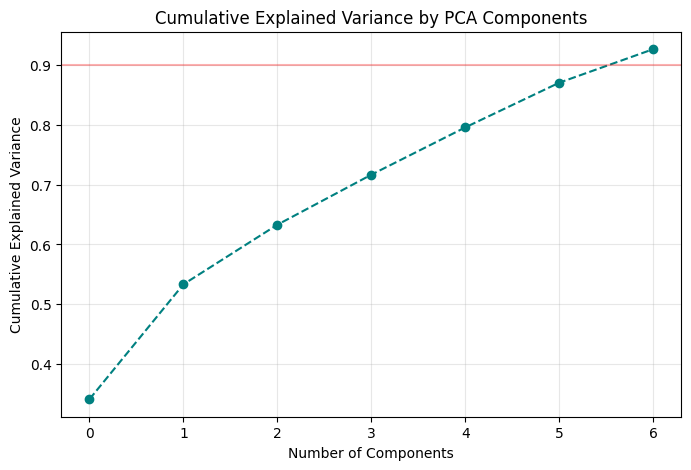

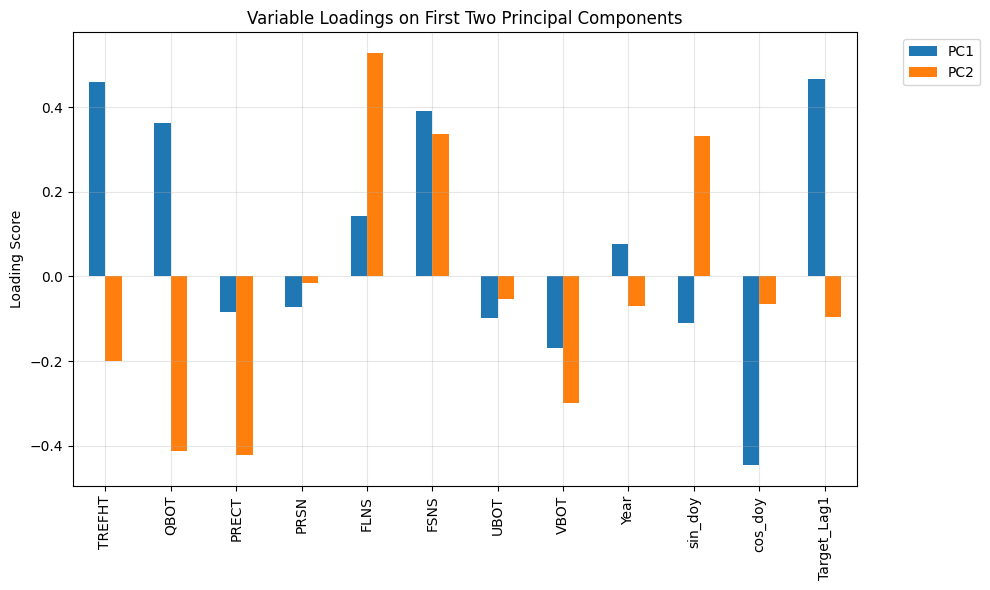

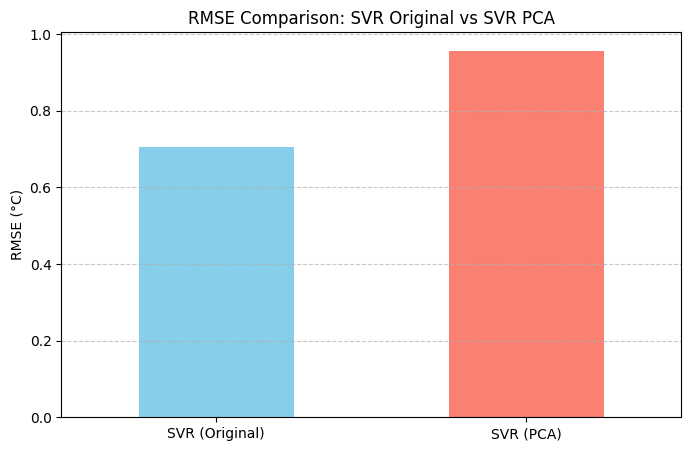

In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Load data for Manchester (lat=5, lon=3)
files = ["003_2006_2080_352_360.nc", "004_2006_2080_352_360.nc", 
         "005_2006_2080_352_360.nc", "006_2006_2080_352_360.nc", 
         "007_2006_2080_352_360.nc", "008_2006_2080_352_360.nc"]

def load_manchester_data(filename):
    with h5py.File(filename, 'r') as f:
        vars_to_load = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 'TREFMXAV_U']
        data_dict = {}
        lat_idx, lon_idx = 5, 3
        for v in vars_to_load:
            d = f[v][:]
            d[d > 1e30] = np.nan
            data_dict[v] = d[:, lat_idx, lon_idx]
        
        df = pd.DataFrame(data_dict)
        df['TREFHT'] -= 273.15
        df['TREFMXAV_U'] -= 273.15
        
        n_days = len(df)
        df['DayOfYear'] = (np.arange(n_days) % 365) + 1
        df['Year'] = 2006 + (np.arange(n_days) // 365)
        df['sin_doy'] = np.sin(2 * np.pi * df['DayOfYear'] / 365)
        df['cos_doy'] = np.cos(2 * np.pi * df['DayOfYear'] / 365)
        df['Target_Lag1'] = df['TREFMXAV_U'].shift(1)
        return df.dropna().reset_index(drop=True)

# 2. Ensemble Split
train_dfs = [load_manchester_data(f) for f in files[:-1]]
df_train = pd.concat(train_dfs, ignore_index=True)
df_test = load_manchester_data(files[-1])

features = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 
            'Year', 'sin_doy', 'cos_doy', 'Target_Lag1']
X_train, y_train = df_train[features], df_train['TREFMXAV_U']
X_test, y_test = df_test[features], df_test['TREFMXAV_U']

# 3. PCA Implementation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#保留90%的方差信息
pca = PCA(n_components=0.90)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

n_components = pca.n_components_
print(f"Number of PCA components to explain 90% variance: {n_components}")

# 4. Modeling & Comparison
# Model A: SVR on Original Scaled Features
print("Training SVR (Original)...")
svr_orig = SVR(kernel='rbf', C=10, epsilon=0.1)
# Use a smaller subset for faster training in this demo env if needed, 
# but we'll try full training as we have 136k samples. 
# Actually, SVR on 136k can be slow. Let's sample 15k for the SVR comparison.
indices = np.random.choice(len(X_train_scaled), 15000, replace=False)
svr_orig.fit(X_train_scaled[indices], y_train.iloc[indices])
y_pred_orig = svr_orig.predict(X_test_scaled)

# Model B: SVR on PCA Features
print("Training SVR (PCA)...")
svr_pca = SVR(kernel='rbf', C=10, epsilon=0.1)
svr_pca.fit(X_train_pca[indices], y_train.iloc[indices])
y_pred_pca = svr_pca.predict(X_test_pca)

# 5. Visualizations
# Plot 1: Cumulative Explained Variance
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--', color='teal')
plt.axhline(y=0.9, color='red', linestyle='-', alpha=0.3)
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True, alpha=0.3)
plt.savefig("pca_variance_plot.png")

# Plot 2: Variable Loadings on PC1 & PC2
# This shows which physical variables dominate the principal components
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(n_components)], index=features)
plt.figure(figsize=(10, 6))
loadings[['PC1', 'PC2']].plot(kind='bar', ax=plt.gca())
plt.title("Variable Loadings on First Two Principal Components")
plt.ylabel("Loading Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pca_loadings_plot.png")

# Plot 3: Metrics Comparison
metrics = {
    'SVR (Original)': [np.sqrt(mean_squared_error(y_test, y_pred_orig)), r2_score(y_test, y_pred_orig)],
    'SVR (PCA)': [np.sqrt(mean_squared_error(y_test, y_pred_pca)), r2_score(y_test, y_pred_pca)]
}
df_metrics = pd.DataFrame(metrics, index=['RMSE', 'R2']).T
df_metrics.to_csv("pca_model_comparison.csv")

plt.figure(figsize=(8, 5))
df_metrics['RMSE'].plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("RMSE Comparison: SVR Original vs SVR PCA")
plt.ylabel("RMSE (°C)")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("pca_metrics_comparison.png")

print(df_metrics)

Loading data...
Training Models...
Generating Master Dashboard...


/var/folders/z_/cgsk2pf150570djfzwp929fc0000gn/T/ipykernel_4778/3406896604.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✅ 成功！全景图片已保存为 'manchester_master_dashboard.png'


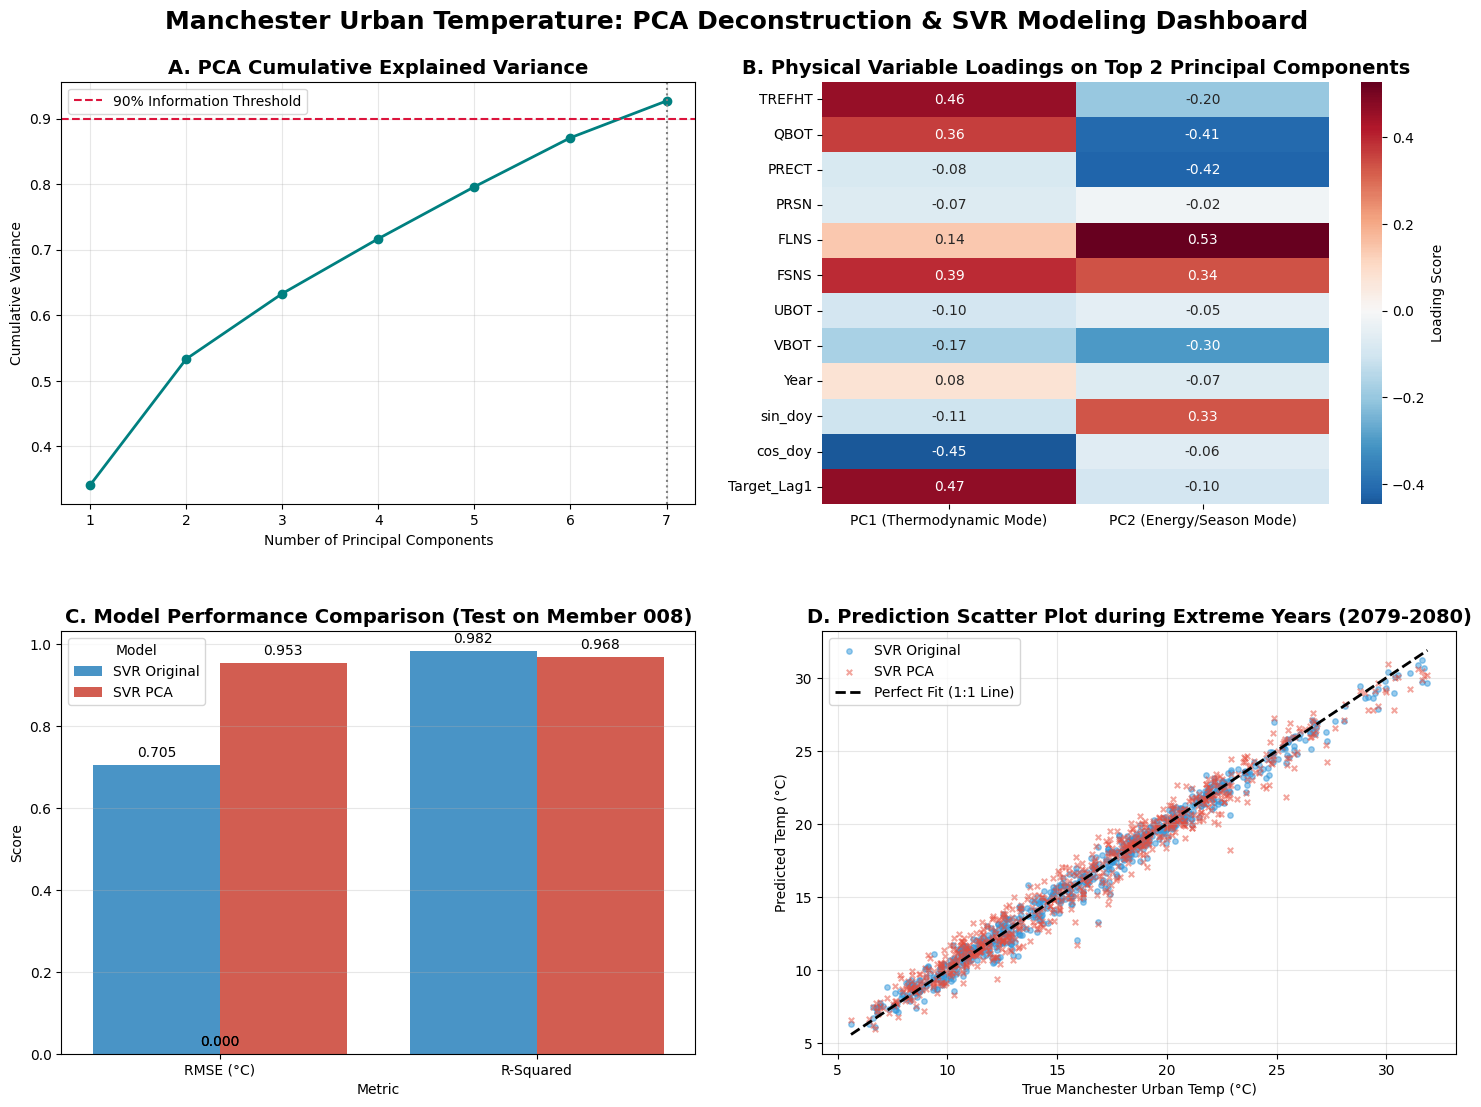

In [3]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. 数据加载与预处理 (保持严谨逻辑)
# ==========================================
files = ["003_2006_2080_352_360.nc", "004_2006_2080_352_360.nc", 
         "005_2006_2080_352_360.nc", "006_2006_2080_352_360.nc", 
         "007_2006_2080_352_360.nc", "008_2006_2080_352_360.nc"]

def load_manchester_data(filename):
    with h5py.File(filename, 'r') as f:
        vars_to_load = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 'TREFMXAV_U']
        lat_idx, lon_idx = 5, 3
        data_dict = {}
        for v in vars_to_load:
            d = f[v][:]
            d[d > 1e30] = np.nan
            data_dict[v] = d[:, lat_idx, lon_idx]
        
        df = pd.DataFrame(data_dict)
        df['TREFHT'] -= 273.15
        df['TREFMXAV_U'] -= 273.15
        
        df['sin_doy'] = np.sin(2 * np.pi * (np.arange(len(df)) % 365 + 1) / 365)
        df['cos_doy'] = np.cos(2 * np.pi * (np.arange(len(df)) % 365 + 1) / 365)
        df['Year'] = 2006 + (np.arange(len(df)) // 365)
        df['Target_Lag1'] = df['TREFMXAV_U'].shift(1)
        return df.dropna().reset_index(drop=True)

print("Loading data...")
train_dfs = [load_manchester_data(f) for f in files[:-1]]
df_train = pd.concat(train_dfs, ignore_index=True)
df_test = load_manchester_data(files[-1])

features = ['TREFHT', 'QBOT', 'PRECT', 'PRSN', 'FLNS', 'FSNS', 'UBOT', 'VBOT', 'Year', 'sin_doy', 'cos_doy', 'Target_Lag1']
X_train, y_train = df_train[features], df_train['TREFMXAV_U']
X_test, y_test = df_test[features], df_test['TREFMXAV_U']

# ==========================================
# 2. PCA降维与模型训练
# ==========================================
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

pca = PCA(n_components=0.90) 
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca = pca.transform(X_test_sc)

np.random.seed(42)
idx = np.random.choice(len(X_train_sc), 15000, replace=False)

print("Training Models...")
svr_orig = SVR(kernel='rbf', C=10, epsilon=0.1).fit(X_train_sc[idx], y_train.iloc[idx])
svr_pca = SVR(kernel='rbf', C=10, epsilon=0.1).fit(X_train_pca[idx], y_train.iloc[idx])

y_pred_orig = svr_orig.predict(X_test_sc)
y_pred_pca = svr_pca.predict(X_test_pca)

rmse_orig = np.sqrt(mean_squared_error(y_test, y_pred_orig))
r2_orig = r2_score(y_test, y_pred_orig)
rmse_pca = np.sqrt(mean_squared_error(y_test, y_pred_pca))
r2_pca = r2_score(y_test, y_pred_pca)

# ==========================================
# 3. 绘制高度整合的“全景仪表盘” (Master Dashboard)
# ==========================================
print("Generating Master Dashboard...")
fig = plt.figure(figsize=(18, 12))
# 使用 GridSpec 将画板分为 2行 2列
gs = GridSpec(2, 2, figure=fig, hspace=0.3, wspace=0.2)

# --- 模块 A (左上): PCA 方差累计曲线 ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(range(1, len(pca.explained_variance_ratio_)+1), 
         np.cumsum(pca.explained_variance_ratio_), 'teal', marker='o', linestyle='-', linewidth=2)
ax1.axhline(0.9, color='crimson', linestyle='--', label='90% Information Threshold')
ax1.axvline(pca.n_components_, color='gray', linestyle=':')
ax1.set_title("A. PCA Cumulative Explained Variance", fontsize=14, fontweight='bold')
ax1.set_xlabel("Number of Principal Components")
ax1.set_ylabel("Cumulative Variance")
ax1.grid(True, alpha=0.3)
ax1.legend()

# --- 模块 B (右上): PCA 特征物理载荷热力图 (深度分析) ---
ax2 = fig.add_subplot(gs[0, 1])
# 提取前两个主成分的特征权重
loadings = pd.DataFrame(pca.components_[:2].T, columns=['PC1 (Thermodynamic Mode)', 'PC2 (Energy/Season Mode)'], index=features)
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=ax2, cbar_kws={'label': 'Loading Score'})
ax2.set_title("B. Physical Variable Loadings on Top 2 Principal Components", fontsize=14, fontweight='bold')

# --- 模块 C (左下): 模型评估指标对比柱状图 ---
ax3 = fig.add_subplot(gs[1, 0])
metrics_df = pd.DataFrame({
    'Metric': ['RMSE (°C)', 'RMSE (°C)', 'R-Squared', 'R-Squared'],
    'Model': ['SVR Original', 'SVR PCA', 'SVR Original', 'SVR PCA'],
    'Value': [rmse_orig, rmse_pca, r2_orig, r2_pca]
})
sns.barplot(x='Metric', y='Value', hue='Model', data=metrics_df, ax=ax3, palette=['#3498db', '#e74c3c'])
# 在柱子上添加具体数值
for p in ax3.patches:
    ax3.annotate(format(p.get_height(), '.3f'), 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
ax3.set_title("C. Model Performance Comparison (Test on Member 008)", fontsize=14, fontweight='bold')
ax3.set_ylabel("Score")
ax3.grid(axis='y', alpha=0.3)

# --- 模块 D (右下): 极端高温年份预测散点拟合图 ---
ax4 = fig.add_subplot(gs[1, 1])
# 截取最后两年看极值拟合情况
mask = df_test['Year'] >= 2079
ax4.scatter(y_test[mask], y_pred_orig[mask], alpha=0.5, color='#3498db', label='SVR Original', s=15)
ax4.scatter(y_test[mask], y_pred_pca[mask], alpha=0.5, color='#e74c3c', label='SVR PCA', marker='x', s=15)
# 添加完美的 1:1 对角线
min_val = min(y_test[mask].min(), y_pred_orig[mask].min())
max_val = max(y_test[mask].max(), y_pred_orig[mask].max())
ax4.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Fit (1:1 Line)')
ax4.set_title("D. Prediction Scatter Plot during Extreme Years (2079-2080)", fontsize=14, fontweight='bold')
ax4.set_xlabel("True Manchester Urban Temp (°C)")
ax4.set_ylabel("Predicted Temp (°C)")
ax4.legend()
ax4.grid(True, alpha=0.3)

# 整体标题与保存
plt.suptitle("Manchester Urban Temperature: PCA Deconstruction & SVR Modeling Dashboard", fontsize=18, fontweight='heavy', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.92) # 为总标题留出空间
plt.savefig("manchester_master_dashboard.png", dpi=300, bbox_inches='tight')
print("✅ 成功！全景图片已保存为 'manchester_master_dashboard.png'")